# Lahjati: Arabic Dialect Classification Using Machine Learning
## IT461 – Practical Machine Learning Project

---

This notebook presents the development of Lahjati, a machine learning project that identifies the Gulf Arabic dialect from recorded audio.

It demonstrates each stage of the process, from data preparation and audio preprocessing to feature extraction, model training, and evaluation.

## Import Libraries & Setup


This section initializes the working environment, imports the required Python libraries, and configures essential settings for reproducibility and organization.

All packages related to signal processing, data manipulation, visualization, and model training are imported here to ensure a clean and consistent runtime.

In [ ]:
# Filtering warnings to provide clean charts
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Required libraries to process the audio data
!pip -q install librosa noisereduce tqdm
%pip -q install -U pip

# Install fsspec, datasets, soundfile, and torchcodec at compatible versions
%pip -q install fsspec==2024.5.0 datasets==2.20.0 soundfile==0.12.1 torchcodec

# NOTE: gcsfs is being temporarily excluded as it causes fsspec version conflicts.
# If gcsfs functionality is later needed, a compatible version or alternative will be necessary.

# Install/update other core libraries
%pip -q install -U numpy librosa soundfile pyloudnorm tqdm
!pip install torchaudio soundfile --quiet
!pip install datasets[audio] --quiet
!pip install -q scikeras==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 14.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.5.0 which is incompatible.


In [ ]:
# Necessary imports
import soundfile as sf
from datasets import get_dataset_config_names, load_dataset_builder
import zipfile, io, pandas as pd, soundfile as sf
import matplotlib.pyplot as plt
import kagglehub
from IPython.display import Audio, display
from collections import Counter
from datasets import load_dataset, Audio
from IPython.display import Audio as IPyAudio
from tqdm import tqdm
import librosa, numpy as np
import noisereduce as nr
from random import uniform
import pyloudnorm as pyln
from sklearn.model_selection import train_test_split
import time
from datasets import Audio as HF_Audio
import os, re
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from scipy.stats import uniform
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from scikeras.wrappers import KerasClassifier
from scipy.stats import randint, uniform
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
import random
import joblib
from IPython.display import Audio, display

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Overview

The Lahjati project integrates two major Arabic dialect datasets to increase coverage and linguistic diversity across regional accents.
By combining data from multiple sources, the model is exposed to a broader range of pronunciation styles, speech environments, and dialectal variations, which strengthens its ability to generalize to unseen Arabic speech samples.

### **Dataset 1: SADA 2022 Dataset (Kaggle)**

The SADA 2022 dataset contributes another extensive collection of Arabic speech recordings sourced from Kaggle.
It enriches Lahjati’s training corpus with additional dialects, natural conversational samples, and more spontaneous speaking styles that differ from the structured recordings in the Casablanca dataset.
This diversity enhances the model’s robustness and its ability to recognize dialectal variations across broader acoustic conditions.

#### Class Distribution:

The following code cell summarizes the dialect distribution within the SADA 2022 dataset, illustrating the representation of each regional category.

In [ ]:
# Display dialect class distribution for the SADA 2022 dataset
csv_paths = [
    "/content/drive/MyDrive/Lahjati/SADA2022/train.csv",
    "/content/drive/MyDrive/Lahjati/SADA2022/valid.csv",
    "/content/drive/MyDrive/Lahjati/SADA2022/test.csv"
]

# Read all three files, keeping only SpeakerDialect
dfs = [pd.read_csv(p, usecols=["SpeakerDialect"]) for p in csv_paths]

# Combine into one DataFrame
df = pd.concat(dfs, ignore_index=True)

# Show distribution (like Casablanca format)
dialect_counts = (
    df["SpeakerDialect"]
    .value_counts()
    .rename_axis("dialect")
    .reset_index(name="num_samples")
)

print(dialect_counts.to_string(index=False))

                          dialect  num_samples
                            Najdi        94611
More than 1 speaker اكثر من متحدث        52501
                           Hijazi        36170
                          Unknown        30867
                          Khaliji        30320
             ModernStandardArabic         4302
                         Egyptian         2172
                        Levantine          966
                    Notapplicable          558
                           Yemeni          407
                          Shamali          146
                           Janubi          103
                         Maghrebi           41
                            Iraqi            2


#### Exploring Audio Samples:

Before processing, a brief exploration of the SADA 2022 folder is performed to verify the structure and quality of the audio clips.
This inspection step lists basic metadata—such as filenames, file paths, and clip durations—and plays a few sample recordings to confirm that the data loads and plays correctly.
It helps ensure that the dataset is readable and that all files follow a consistent format before further segmentation or labeling.

In [ ]:
# Display filenames, paths, and durations for the first three SADA audio samples
dataset_path = "/content/drive/MyDrive/Lahjati/SADA2022"
wav_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(".wav")]

print("Columns: ['filename', 'path', 'duration (sec)']")
print("\nFirst 5 rows (sample values):")

for i, f in enumerate(wav_files[:5], start=1):
    path = os.path.join(dataset_path, f)
    try:
        audio_array, sr = sf.read(path, dtype='float32')
        duration = len(audio_array) / sr
        print(f"\nRow {i}:")
        print("  filename:", f)
        print("  path:", path)
        print(f"  duration: {duration:.2f} sec")
        display(Audio(audio_array, rate=sr))
    except Exception as e:
        print(f"\nRow {i}: could not read {f} ({e})")

### **Dataset 2: Casablanca Dataset (UBC-NLP)**

The Casablanca dataset, released by UBC-NLP and hosted on Hugging Face, provides labeled Arabic speech recordings representing a variety of regional dialects.
Each entry consists of a .wav audio file paired with metadata specifying both the dialect label and the speaker information.
This dataset forms the foundation of Lahjati’s initial training corpus and offers a balanced distribution across multiple dialect categories.

#### Class Distribution:

The following code cell lists the available subsets (dialect groups) within the Casablanca dataset and their respective sample counts.

In [ ]:
# List all Casablanca dialect subsets and display their sample counts
dataset_id = "UBC-NLP/Casablanca"

configs = get_dataset_config_names(dataset_id)
print("Available subsets:", configs)

records = []
for cfg in configs:
    b = load_dataset_builder(dataset_id, name=cfg)
    total = 0
    for split_name, split_info in b.info.splits.items():
        total += split_info.num_examples or 0
    records.append({"subset": cfg, "num_samples": total})

casablanca_counts = pd.DataFrame(records).sort_values("num_samples", ascending=False)
display(casablanca_counts)

Available subsets: ['Algeria', 'Egypt', 'Jordan', 'Mauritania', 'Morocco', 'Palestine', 'UAE', 'Yemen']


,subset,num_samples
4,Morocco,2090
3,Mauritania,1906
2,Jordan,1696
1,Egypt,1692
0,Algeria,1687
6,UAE,1626
7,Yemen,1606
5,Palestine,1334


#### Exploring Dataset Subsets:

Before processing, each subset of the Casablanca dataset—representing a specific country or dialect group—is explored individually.
This step allows verification of the dataset structure, available splits, and the number of samples per dialect subset prior to merging.

In [ ]:
# Load and inspect a specific Casablanca subset
subset = "Algeria"

# Load {'validation': Dataset, 'test': Dataset}
ds_dict = load_dataset("UBC-NLP/Casablanca", name=subset, streaming=False)

# Try to make 'audio' column decoded (no 'backend' parameter)
try:
    for k in ds_dict.keys():
        ds_dict[k] = ds_dict[k].cast_column("audio", Audio(decode=True))
    decode_mode = "datasets+soundfile (auto)"
except Exception as e:
    decode_mode = f"manual soundfile (fallback) due to: {e}"

# Show splits and sizes
available_splits = list(ds_dict.keys())
print(f"Available splits for {subset}:", available_splits)
for split_name, split_ds in ds_dict.items():
    print(f"  → {split_name}: {len(split_ds)} rows")
print("Decoding mode:", decode_mode)

# Preview 5 rows with audio
split = available_splits[0]
ds = ds_dict[split]
print("\nColumn names:", ds.column_names)
print("\nFirst 5 rows (sample values):")

for i in range(min(5, len(ds))):
    row = ds[i]
    print(f"\nRow {i+1}:")
    print("  seg_id:", row.get("seg_id"))
    print("  transcription:", row.get("transcription"))
    print("  gender:", row.get("gender"))
    print("  duration:", row.get("duration"))

    # If auto-decoding worked, 'audio' has 'array' and 'sampling_rate'
    a = row["audio"]
    if isinstance(a, dict) and "array" in a and a["array"] is not None:
        display(IPyAudio(a["array"], rate=a["sampling_rate"]))
    else:
        # Manual fallback: read from the stored path
        path = a["path"] if isinstance(a, dict) else a
        audio_array, sr = sf.read(path, dtype="float32")
        display(IPyAudio(audio_array, rate=sr))

Generating validation split:   0%|          | 0/844 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/843 [00:00<?, ? examples/s]

Available splits for Algeria: ['validation', 'test']
  → validation: 844 rows
  → test: 843 rows
Decoding mode: datasets+soundfile (auto)

Column names: ['audio', 'seg_id', 'transcription', 'gender', 'duration']

First 5 rows (sample values):

Row 1:
  seg_id: 11175_4
  transcription: مدهالله خير
  gender: Missing
  duration: 0.9225402725



Row 2:
  seg_id: 11175_6
  transcription: هاوترييي
  gender: Missing
  duration: 1.69327012



Row 3:
  seg_id: 11176_2
  transcription: فهمت
  gender: Missing
  duration: 0.2550114068



Row 4:
  seg_id: 11177_2
  transcription: حبيتك تعاوني بش نحبسو الزواج
  gender: Missing
  duration: 1.773081274



Row 5:
  seg_id: 11178_2
  transcription: بش تسلك باباها
  gender: Missing
  duration: 1.312785171


## Data Integration

To create a more comprehensive and balanced dataset, both sources are merged into a single unified collection.

This integration ensures better coverage across dialect groups and improved model generalization.

### Process Datasets Individually

Each source dataset is processed independently to handle its unique structure, labeling style, and formatting before merging.

This step includes dataset-specific cleaning, filtering, or adjustments to ensure consistency in the integrated dataset.

#### **Dataset 1: SADA 2022 Dataset (Kaggle)**


##### **Choosing segments**

A controlled selection of short, speech-only segments is extracted from the SADA dataset to maintain uniform clip length and minimize background noise.
This process focuses on generating balanced samples of approximately 3 to 4 seconds each, ensuring consistency in duration and quality before any further preprocessing or normalization.

In [ ]:
import os
import pandas as pd
import numpy as np
import soundfile as sf

# -------------------------------------------------
# 1. Load metadata
# -------------------------------------------------
csv_paths = [
    "/content/drive/MyDrive/Lahjati/SADA2022/train.csv",
    "/content/drive/MyDrive/Lahjati/SADA2022/valid.csv",
    "/content/drive/MyDrive/Lahjati/SADA2022/test.csv"
]

df_list = [pd.read_csv(p) for p in csv_paths]
meta = pd.concat(df_list, ignore_index=True)

# -------------------------------------------------
# 2. Filter dialects → Saudi only
# -------------------------------------------------
saudi_set = {"Najdi", "Hijazi", "Khaliji", "Shamali", "Janubi"}
meta = meta[meta["SpeakerDialect"].isin(saudi_set)].copy()
meta["dialect"] = "Saudi"

# -------------------------------------------------
# 3. Fix filenames: strip batch folders
# -------------------------------------------------
meta["clean_name"] = meta["FileName"].apply(lambda x: os.path.basename(str(x)))

# ensure no NaNs
meta = meta.dropna(subset=["SegmentStart", "SegmentEnd"])

# -------------------------------------------------
# 4. Keep segments 3–6 seconds
# -------------------------------------------------
meta["seg_len"] = meta["SegmentEnd"] - meta["SegmentStart"]
meta = meta[(meta["seg_len"] >= 3.0) & (meta["seg_len"] <= 6.0)]

# Remove duplicates by transcript
meta = meta.drop_duplicates(subset=["GroundTruthText"], keep="first")

print("After filtering:", len(meta), "valid segments")

# -------------------------------------------------
# 5. Prepare directories
# -------------------------------------------------
AUDIO_DIR = "/content/drive/MyDrive/Lahjati/SADA2022"
OUT_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_clips"

os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------------------------------
# 6. Extract up to 500 clips
# -------------------------------------------------
rows = []
saved = 0
TARGET = 1500

groups = meta.groupby("clean_name")

for clean_name, group in groups:
    if saved >= TARGET:
        break

    wav_path = os.path.join(AUDIO_DIR, clean_name)

    if not os.path.isfile(wav_path):
        print("Missing:", clean_name)
        continue

    # load original wav
    try:
        y, sr = sf.read(wav_path)
    except Exception as e:
        print("Failed to load:", clean_name, e)
        continue

    for _, row in group.iterrows():
        if saved >= TARGET:
            break

        start = int(row["SegmentStart"] * sr)
        end   = int(row["SegmentEnd"] * sr)

        if start < 0 or end > len(y):
            continue

        clip = y[start:end]
        dur = len(clip) / sr

        if dur < 3 or dur > 6:
            continue

        out_name = f"{os.path.splitext(clean_name)[0]}_seg_{saved}.wav"
        out_path = os.path.join(OUT_DIR, out_name)

        try:
            sf.write(out_path, clip, sr)
        except:
            continue

        rows.append({
            "path": out_path,
            "duration": dur,
            "dialect": "Saudi"
        })

        saved += 1

print(f"\nSaved {saved} Saudi speech clips.")

# -------------------------------------------------
# 7. Save final CSV
# -------------------------------------------------
final_df = pd.DataFrame(rows)
save_path = "/content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv"
final_df.to_csv(save_path, index=False)

print("Saved CSV:", save_path)
print(final_df.head())

After filtering: 36778 valid segments
Missing: 6k_SBA_100_0.wav
Missing: 6k_SBA_100_1.wav
Missing: 6k_SBA_100_2.wav
Missing: 6k_SBA_100_3.wav
Missing: 6k_SBA_102_1.wav
Missing: 6k_SBA_102_2.wav
Missing: 6k_SBA_119_0.wav
Missing: 6k_SBA_122_0.wav
Missing: 6k_SBA_124_2.wav
Missing: 6k_SBA_126_0.wav
Missing: 6k_SBA_126_1.wav
Missing: 6k_SBA_126_2.wav
Missing: 6k_SBA_22_0.wav
Missing: 6k_SBA_22_1.wav
Missing: 6k_SBA_22_2.wav
Missing: 6k_SBA_22_3.wav
Missing: 6k_SBA_22_4.wav
Missing: 6k_SBA_23_0.wav
Missing: 6k_SBA_24_0.wav
Missing: 6k_SBA_26_2.wav
Missing: 6k_SBA_26_4.wav
Missing: 6k_SBA_39_0.wav
Missing: 6k_SBA_39_1.wav
Missing: 6k_SBA_39_2.wav
Missing: 6k_SBA_41_0.wav
Missing: 6k_SBA_41_1.wav
Missing: 6k_SBA_41_2.wav
Missing: 6k_SBA_43_1.wav
Missing: 6k_SBA_43_2.wav

Saved 1500 Saudi speech clips.
Saved CSV: /content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv
                                                path  duration dialect
0  /content/drive/MyDrive/Lahjati/Lahjati_clips/6

#### **Dataset 2: Casablanca Dataset (UBC-NLP)**


##### **Merge all Casablanca subsets**

All eight Casablanca subsets are combined into a single dataset containing the columns path, duration, and dialect.

This consolidation step ensures uniform organization and labeling across the merged data, preparing it for the integration phase.

In [ ]:
# ============================================
# Merge Casablanca subsets into Lahjati_clips
# and APPEND to lahjati_integrated_dataset.csv
# ============================================
import os
import soundfile as sf
import pandas as pd
from datasets import load_dataset, get_dataset_config_names, Audio as HF_Audio

# ---- 1) Paths (match your friend’s paths) ----
OUT_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_clips"
CSV_PATH = "/content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 2) Target quotas per dialect ----
quota = {
    "Mauritania": 600,
    "Morocco": 600,
    "Algeria": 600,
    "Jordan": 0,
    "Palestine": 600,
    "UAE": 1500,
    "Egypt": 600,
    "Yemen": 0,
}

# ---- 3) Check what is ALREADY in the CSV ----
# (so we don't duplicate if you re-run the cell)
if os.path.exists(CSV_PATH):
    base_df = pd.read_csv(CSV_PATH)
    existing_counts = base_df["dialect"].value_counts()
else:
    base_df = None
    existing_counts = {}

remaining = {}
for d, q in quota.items():
    already = int(existing_counts.get(d, 0))
    remaining[d] = max(q - already, 0)

print("Existing per dialect in CSV:")
print(existing_counts.reindex(quota.keys()).fillna(0).astype(int))
print("\nRemaining to collect per dialect:")
print(remaining)

rng = 42

# ---- 4) Helper to avoid overwriting WAV files ----
def unique_path(dest_dir, stem):
    p = os.path.join(dest_dir, f"{stem}.wav")
    k = 1
    while os.path.exists(p):
        p = os.path.join(dest_dir, f"{stem}_{k}.wav")
        k += 1
    return p

# ---- 5) Collect Casablanca clips ----
rows = []

for subset in get_dataset_config_names("UBC-NLP/Casablanca"):
    # subset name is the dialect label in this dataset
    need = remaining.get(subset, 0)
    if need <= 0:
        continue  # we already have enough for this dialect

    ds_dict = load_dataset("UBC-NLP/Casablanca", name=subset, streaming=False)

    for split_name, ds in ds_dict.items():
        if remaining[subset] <= 0:
            break

        # ensure HF Audio objects, not display objects
        ds = ds.cast_column("audio", HF_Audio())

        take = min(remaining[subset], len(ds))
        if take <= 0:
            continue

        ds_small = ds.shuffle(seed=rng).select(range(take))

        for row in ds_small:
            a = row["audio"]
            y = a["array"]           # raw audio
            sr = a["sampling_rate"]  # original sampling rate

            stem = f"{subset}_{row.get('seg_id', 'clip')}"
            out_path = unique_path(OUT_DIR, stem)  # <-- will NOT overwrite
            sf.write(out_path, y, sr)

            duration = len(y) / sr
            rows.append({
                "path": out_path,
                "duration": duration,
                "dialect": subset
            })

        remaining[subset] -= take

# ---- 6) Create Casablanca DataFrame ----
casablanca_final = pd.DataFrame(
    rows,
    columns=["path", "duration", "dialect"]
).reset_index(drop=True)

print(f"\nNew Casablanca clips created: {len(casablanca_final)}")
print("Per dialect (newly added):")
print(casablanca_final["dialect"].value_counts().reindex(quota.keys()).fillna(0).astype(int))

# ---- 7) Append to existing integrated CSV ----
if base_df is not None:
    integrated_df = pd.concat([base_df, casablanca_final], ignore_index=True)
else:
    integrated_df = casablanca_final

integrated_df.to_csv(CSV_PATH, index=False)

print("\nSaved updated integrated CSV to:", CSV_PATH)
print("Total rows after merge:", len(integrated_df))
print("Total per dialect:")
print(integrated_df["dialect"].value_counts())

Existing per dialect in CSV:
dialect
Mauritania    0
Morocco       0
Algeria       0
Jordan        0
Palestine     0
UAE           0
Egypt         0
Yemen         0
Name: count, dtype: int64

Remaining to collect per dialect:
{'Mauritania': 600, 'Morocco': 600, 'Algeria': 600, 'Jordan': 0, 'Palestine': 600, 'UAE': 1500, 'Egypt': 600, 'Yemen': 0}


Generating validation split:   0%|          | 0/844 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/843 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/846 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/846 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/667 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/667 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/813 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/813 [00:00<?, ? examples/s]


New Casablanca clips created: 4500
Per dialect (newly added):
dialect
Mauritania     600
Morocco        600
Algeria        600
Jordan           0
Palestine      600
UAE           1500
Egypt          600
Yemen            0
Name: count, dtype: int64

Saved updated integrated CSV to: /content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv
Total rows after merge: 6000
Total per dialect:
dialect
Saudi         1500
UAE           1500
Algeria        600
Egypt          600
Mauritania     600
Morocco        600
Palestine      600
Name: count, dtype: int64


## Audio Preprocessing

The audio preprocessing stage standardizes all recordings into a uniform, high-quality format that is suitable for feature extraction.

This process ensures that every file shares the same sampling characteristics and removes unwanted variations, noise, or silence that could negatively affect learning outcomes.

### Resampling

In this step, all audio files are converted to mono and resampled to a 16 kHz sampling rate.
Resampling ensures that all clips follow the same frequency standard, improving consistency and compatibility across datasets during feature extraction.

In [ ]:
# Resample all audio clips in Lahjati_audio_clips to 16 kHz mono format
SRC_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_clips"       # Original folder
DST_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_audio_clips_16k"   # Folder to save resampled files
TARGET_SR = 16000

os.makedirs(DST_DIR, exist_ok=True)

records = []
n_ok, n_done, n_err = 0, 0, 0

def ensure_mono(y: np.ndarray) -> np.ndarray:
    """Convert stereo signal to mono if needed"""
    if y.ndim == 2:
        # Handle both (channels, time) and (time, channels) formats
        if y.shape[0] < y.shape[1]:
            y = y.mean(axis=0)
        else:
            y = y.mean(axis=1)
    return y

# Collect all .wav files inside the source directory (including subfolders)
wav_files = []
for root, _, files in os.walk(SRC_DIR):
    for fn in files:
        if fn.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, fn))

# Process each file
for src_path in tqdm(wav_files, desc="Resampling"):
    rel = os.path.relpath(src_path, SRC_DIR)          # Keep the same folder structure
    dst_path = os.path.join(DST_DIR, rel)
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    try:
        # Load audio without automatic resampling
        y, sr = librosa.load(src_path, sr=None, mono=False)
        orig_channels = 1 if (np.ndim(y)==1) else (y.shape[0] if y.shape[0] < y.shape[1] else y.shape[1])

        # Convert to mono
        y = ensure_mono(np.array(y))

        # Resample if sample rate is not 16 kHz
        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
            new_sr = TARGET_SR
        else:
            new_sr = sr

        # Save the resampled file
        sf.write(dst_path, y, new_sr, subtype="PCM_16")

        # Record stats for the report
        duration_sec = len(y) / new_sr
        records.append({
            "src_path": src_path,
            "dst_path": dst_path,
            "orig_sr": sr,
            "orig_channels": orig_channels,
            "new_sr": new_sr,
            "new_channels": 1,  # All converted to mono
            "duration_sec": duration_sec
        })
        n_done += 1

    except Exception as e:
        # Handle and log any errors
        n_err += 1
        records.append({
            "src_path": src_path,
            "dst_path": None,
            "orig_sr": None,
            "orig_channels": None,
            "new_sr": None,
            "new_channels": None,
            "duration_sec": None,
            "error": str(e)
        })


print("Done")
print("Total files:", len(wav_files), "| Converted:", n_done, "| Errors:", n_err)

Resampling: 100%|██████████| 6000/6000 [10:27<00:00,  9.56it/s]

Done
Total files: 6000 | Converted: 6000 | Errors: 0


### Trim Silence




This step removes silence and irrelevant background sections from each audio clip.
By trimming the recordings to keep only the speech-active parts, the dataset becomes cleaner, smaller, and more focused on the actual spoken content.

In [ ]:
# Trim silence and retain only speech segments from Lahjati audio clips
SRC_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_audio_clips_16k"   # Folder containing resampled audio
DST_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_cleaned"           # Folder to save cleaned audio
os.makedirs(DST_DIR, exist_ok=True)

for root, _, files in os.walk(SRC_DIR):
    for fn in tqdm(files, desc=f"Processing {root}"):
        if fn.lower().endswith(".wav"):
            src_path = os.path.join(root, fn)
            dst_path = os.path.join(DST_DIR, fn)

            try:
                # Load the audio (mono, 16kHz)
                y, sr = librosa.load(src_path, sr=16000)

                # Step 1: Trim silence (removes quiet parts at start and end)
                y_trimmed, _ = librosa.effects.trim(y, top_db=20)

                # Save the cleaned audio
                sf.write(dst_path, y_trimmed, sr, subtype="PCM_16")

            except Exception as e:
                print(f"⚠️ Error with file {fn}: {e}")

print("All files processed and saved to:", DST_DIR)


Processing /content/drive/MyDrive/Lahjati/Lahjati_audio_clips_16k: 100%|██████████| 6000/6000 [03:28<00:00, 28.78it/s]

All files processed and saved to: /content/drive/MyDrive/Lahjati/Lahjati_cleaned


### Noise Handling


In this step, background noise is reduced to improve clarity and consistency across all processed clips.
Using the noisereduce library, each file’s noise profile is analyzed, and unwanted background sounds are removed while keeping speech natural.
The denoised outputs are stored in the Lahjati_denoised_clips folder to ensure high-quality input for the next stages.

In [ ]:
# Apply background noise reduction and save denoised clips to Lahjati_denoised_clips
SRC_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_cleaned"   # Input: cleaned audio
DST_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_denoised_clips"  # Output: denoised audio
os.makedirs(DST_DIR, exist_ok=True)

# Initialize report
records = []

# Parameters
TARGET_SR = 16000
NOISE_REDUCTION_LEVEL = 0.9  # lower = less aggressive (try 0.7–0.9)

# Process files
print(f"🎧 Starting noise reduction for files in: {SRC_DIR}\n")
for root, _, files in os.walk(SRC_DIR):
    for fname in tqdm(files, desc="Reducing Noise"):
        if not fname.lower().endswith(".wav"):
            continue

        src_path = os.path.join(root, fname)
        dst_path = os.path.join(DST_DIR, fname)

        try:
            # Load audio
            y, sr = librosa.load(src_path, sr=TARGET_SR, mono=True)
            duration_before = len(y) / sr

            # Apply noise reduction
            y_denoised = nr.reduce_noise(y=y, sr=sr, prop_decrease=NOISE_REDUCTION_LEVEL)

            # Save denoised file
            sf.write(dst_path, y_denoised, sr, subtype="PCM_16")

            duration_after = len(y_denoised) / sr
            records.append({
                "filename": fname,
                "source_path": src_path,
                "output_path": dst_path,
                "sample_rate": sr,
                "duration_before": round(duration_before, 3),
                "duration_after": round(duration_after, 3),
                "status": "Processed",
                "error": None
            })

        except Exception as e:
            print(f"⚠️ Error processing {fname}: {e}")
            records.append({
                "filename": fname,
                "source_path": src_path,
                "output_path": None,
                "status": "Error",
                "error": str(e)
            })

# Save
report_path = "/content/drive/MyDrive/Lahjati/noise_reduction_report.csv"
pd.DataFrame(records).to_csv(report_path, index=False)

print("\nNoise reduction complete!")
print(f"Processed files saved in: {DST_DIR}")
print(f"Report saved at: {report_path}")


🎧 Starting noise reduction for files in: /content/drive/MyDrive/Lahjati/Lahjati_cleaned



Reducing Noise: 100%|██████████| 6000/6000 [09:56<00:00, 10.07it/s]



Noise reduction complete!
Processed files saved in: /content/drive/MyDrive/Lahjati/Lahjati_denoised_clips
Report saved at: /content/drive/MyDrive/Lahjati/noise_reduction_report.csv


### Volume Normalization

After cleaning, all clips undergo volume normalization to equalize loudness levels across recordings.
This ensures that louder speakers or recording conditions do not dominate training.
Each file is normalized to a consistent target loudness (−23 LUFS) and a peak ceiling (−1 dBFS), maintaining natural but balanced amplitude levels.

In [ ]:
# Normalize volume levels of all cleaned clips to a fixed loudness and peak limit
SRC_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_denoised_clips"     # input (already cleaned)
DST_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_normalized_clips"  # output folder
os.makedirs(DST_DIR, exist_ok=True)

# ====== Normalization parameters ======
TARGET_LUFS     = -23.0   # main target loudness
PEAK_DBFS       = -1.0    # hard peak ceiling
LUFS_BLOCK_SEC  = 0.20    # smaller block size to accept shorter clips
MIN_LUFS_SEC    = 0.25    # if shorter than this, fallback to peak normalization

def peak_dbfs(x: np.ndarray) -> float:
    peak = float(np.max(np.abs(x))) + 1e-12
    return 20.0 * np.log10(peak)

def peak_normalize(y: np.ndarray, target_peak_dbfs: float) -> np.ndarray:
    """Simple peak normalization to a target dBFS. No LUFS measurement."""
    peak_now_db = peak_dbfs(y)
    if not np.isfinite(peak_now_db):  # all zeros
        return y.astype(np.float32)
    gain_db = target_peak_dbfs - peak_now_db
    gain = 10.0 ** (gain_db / 20.0)
    y_out = (y * gain).astype(np.float32)
    y_out = np.clip(y_out, -0.999, 0.999).astype(np.float32)
    return y_out

def lufs_normalize_with_peak_ceiling(y: np.ndarray, sr: int) -> np.ndarray:
    """LUFS normalize to TARGET_LUFS with smaller block size, then peak-limit."""
    # Measure LUFS on mono ref but apply to original channels
    if y.ndim == 2:  # (frames, channels)
        y_ref = y.mean(axis=1)
    else:
        y_ref = y

    meter = pyln.Meter(sr, block_size=LUFS_BLOCK_SEC)  # smaller block for short clips
    loud = meter.integrated_loudness(y_ref)

    gain_db = TARGET_LUFS - loud
    gain = 10.0 ** (gain_db / 20.0)
    y_out = (y * gain).astype(np.float32)

    # Peak ceiling
    cur_peak_db = peak_dbfs(y_out)
    if cur_peak_db > PEAK_DBFS:
        extra_gain_db = PEAK_DBFS - cur_peak_db
        extra = 10.0 ** (extra_gain_db / 20.0)
        y_out = (y_out * extra).astype(np.float32)

    y_out = np.clip(y_out, -0.999, 0.999).astype(np.float32)
    return y_out

# ====== Collect files ======
wav_files = []
for root, _, files in os.walk(SRC_DIR):
    for fn in files:
        if fn.lower().endswith(".wav"):
            wav_files.append(os.path.join(root, fn))

print(f"Found {len(wav_files)} .wav files to normalize.")

# ====== Process (LUFS when possible; fallback to peak for very short clips) ======
ok = err = 0
fallback_used = 0
for src_path in tqdm(wav_files, desc="Normalizing"):
    try:
        rel_path = os.path.relpath(src_path, SRC_DIR)
        dst_path = os.path.join(DST_DIR, rel_path)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)

        y, sr = sf.read(src_path, dtype="float32", always_2d=False)  # keep original sr/channels
        if y is None or (isinstance(y, np.ndarray) and y.size == 0):
            # Empty file; write as-is
            sf.write(dst_path, y, sr, subtype="PCM_16")
            ok += 1
            continue

        duration_sec = float(len(y) / sr) if y.ndim == 1 else float(y.shape[0] / sr)

        if duration_sec < max(LUFS_BLOCK_SEC, MIN_LUFS_SEC):
            # Too short for LUFS: use peak normalization only
            y_norm = peak_normalize(y, PEAK_DBFS)
            fallback_used += 1
        else:
            # Try LUFS; if it still fails, fallback to peak
            try:
                y_norm = lufs_normalize_with_peak_ceiling(y, sr)
            except Exception:
                y_norm = peak_normalize(y, PEAK_DBFS)
                fallback_used += 1

        sf.write(dst_path, y_norm, sr, subtype="PCM_16")
        ok += 1
    except Exception as e:
        err += 1
        print(f"Error processing {src_path}: {e}")

print(f"\n✅ Done. Normalized: {ok} | Errors: {err} | Peak-only fallback used on: {fallback_used}")
print("Output folder:", DST_DIR)

Found 6000 .wav files to normalize.


Normalizing: 100%|██████████| 6000/6000 [04:04<00:00, 24.53it/s]


✅ Done. Normalized: 6000 | Errors: 0 | Peak-only fallback used on: 1
Output folder: /content/drive/MyDrive/Lahjati/Lahjati_normalized_clips


### Framing & Windowing

Once normalized, each audio clip is segmented into short overlapping frames to capture temporal speech dynamics.
This process divides the waveform into small analysis windows (typically 20–40 ms) that preserve time–frequency information, which is essential for extracting MFCC and other acoustic features later.

In [ ]:
# Segment normalized clips into overlapping frames for feature extraction
SRC_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_normalized_clips"   # source normalized WAVs
OUT_FRAMES_DIR = "/content/drive/MyDrive/Lahjati/Lahjati_processed_frames"
OUT_AUDIO_DIR  = "/content/drive/MyDrive/Lahjati/Lahjati_processed_clips_audio"
METADATA_CSV   = "/content/drive/MyDrive/Lahjati/Lahjati_processed_metadata.csv"

# Framing params (standard)
TARGET_SR    = 16000   # expected sample rate
FRAME_MS     = 25      # frame length in ms
HOP_MS       = 10      # hop length in ms
PRE_EMPH     = 0.97    # pre-emphasis coefficient
WINDOW_TYPE  = 'hamming'
MIN_DURATION = 0.05    # skip files shorter than 50 ms

# Prepare output dirs
import os
os.makedirs(OUT_FRAMES_DIR, exist_ok=True)
os.makedirs(OUT_AUDIO_DIR, exist_ok=True)

# Helper functions
def pre_emphasis(signal, coeff=0.97):
    """Apply pre-emphasis: y[t] = x[t] - coeff * x[t-1]."""
    if signal.size == 0:
        return signal
    return np.append(signal[0], signal[1:] - coeff * signal[:-1])

def frame_signal(sig, frame_len, hop_len):
    """
    Convert 1D signal to 2D frames (num_frames, frame_len).
    Pads to include final partial frame.
    """
    sig_len = len(sig)
    if sig_len < frame_len:
        sig = np.concatenate([sig, np.zeros(frame_len - sig_len, dtype=sig.dtype)])
        sig_len = len(sig)

    num_frames = 1 + (sig_len - frame_len) // hop_len
    if (sig_len - frame_len) % hop_len != 0:
        num_frames += 1
        pad_total = (num_frames - 1) * hop_len + frame_len - sig_len
        sig = np.concatenate([sig, np.zeros(pad_total, dtype=sig.dtype)])

    frames = np.lib.stride_tricks.as_strided(
        sig,
        shape=(num_frames, frame_len),
        strides=(sig.strides[0]*hop_len, sig.strides[0])
    ).copy()
    return frames

def apply_window(frames, win_type='hamming'):
    """Apply window (Hamming by default) to each frame."""
    if win_type == 'hamming':
        win = np.hamming(frames.shape[1])
    else:
        win = np.ones(frames.shape[1])
    return frames * win

def reconstruct_signal_from_frames(frames, hop_len):
    """Overlap-add reconstruction from frames (for quick listening)."""
    num_frames, frame_len = frames.shape
    out_len = hop_len * (num_frames - 1) + frame_len
    out = np.zeros(out_len, dtype=frames.dtype)
    wsum = np.zeros(out_len, dtype=frames.dtype)
    for i in range(num_frames):
        start = i * hop_len
        out[start:start+frame_len] += frames[i]
        wsum[start:start+frame_len] += 1.0
    nonzero = wsum > 1e-8
    out[nonzero] = out[nonzero] / wsum[nonzero]
    return out

# Derived values
frame_len = int(round(FRAME_MS * TARGET_SR / 1000.0))
hop_len   = int(round(HOP_MS * TARGET_SR / 1000.0))
print(f"Frame length = {frame_len} samples, hop length = {hop_len} samples (sr={TARGET_SR})")

# Collect WAV files
wav_files = []
for root, _, files in os.walk(SRC_DIR):
    for fn in files:
        if fn.lower().endswith('.wav'):
            wav_files.append(os.path.join(root, fn))
print(f"Found {len(wav_files)} WAV files in: {SRC_DIR}")

# Main processing loop
metadata = []
for wav_path in tqdm(sorted(wav_files), desc="Framing & Windowing"):
    try:
        # Read file (soundfile used in setup)
        y, sr = sf.read(wav_path, dtype='float32')
        if y.ndim == 2:  # stereo -> mono
            y = y.mean(axis=1)

        # Resample if needed
        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
            sr = TARGET_SR

        duration = len(y) / sr
        if duration < MIN_DURATION:
            metadata.append({
                "file_name": os.path.basename(wav_path),
                "path": wav_path,
                "duration": duration,
                "num_frames": 0,
                "status": "too_short"
            })
            continue

        # 1) Pre-emphasis
        y_pre = pre_emphasis(y, coeff=PRE_EMPH)

        # 2) Framing
        frames = frame_signal(y_pre, frame_len=frame_len, hop_len=hop_len)

        # 3) Windowing
        frames_win = apply_window(frames, win_type=WINDOW_TYPE)

        # Save frames (.npy)
        base = os.path.splitext(os.path.basename(wav_path))[0]
        out_npy = os.path.join(OUT_FRAMES_DIR, base + ".npy")
        np.save(out_npy, frames_win.astype(np.float32), allow_pickle=False)

        # Reconstruct & invert pre-emphasis for listening
        recon = reconstruct_signal_from_frames(frames_win, hop_len=hop_len)
        x_inv = np.zeros_like(recon)
        if len(recon) > 0:
            x_inv[0] = recon[0]
            for i in range(1, len(recon)):
                x_inv[i] = recon[i] + PRE_EMPH * x_inv[i-1]
        x_inv = np.clip(x_inv, -0.999, 0.999).astype(np.float32)
        out_wav = os.path.join(OUT_AUDIO_DIR, base + "_recon.wav")
        sf.write(out_wav, x_inv, TARGET_SR, subtype='PCM_16')

        metadata.append({
            "file_name": os.path.basename(wav_path),
            "path": wav_path,
            "duration": round(duration, 3),
            "num_frames": int(frames_win.shape[0]),
            "frame_len": int(frame_len),
            "hop_len": int(hop_len),
            "npy_path": out_npy,
            "recon_path": out_wav,
            "status": "processed"
        })

    except Exception as e:
        metadata.append({
            "file_name": os.path.basename(wav_path),
            "path": wav_path,
            "duration": None,
            "num_frames": 0,
            "status": f"error: {str(e)[:120]}"
        })
        print(f"Error processing {wav_path}: {e}")

# Save
df_meta = pd.DataFrame(metadata)
df_meta.to_csv(METADATA_CSV, index=False)

print("Framing & Windowing complete.")
print("Frames saved to:", OUT_FRAMES_DIR )
print("Reconstructed audio saved to:", OUT_AUDIO_DIR)
print("Metadata CSV saved to:", METADATA_CSV)


Frame length = 400 samples, hop length = 160 samples (sr=16000)
Found 6000 WAV files in: /content/drive/MyDrive/Lahjati/Lahjati_normalized_clips


Framing & Windowing: 100%|██████████| 6000/6000 [10:51<00:00,  9.20it/s]


Framing & Windowing complete.
Frames saved to: /content/drive/MyDrive/Lahjati/Lahjati_processed_frames
Reconstructed audio saved to: /content/drive/MyDrive/Lahjati/Lahjati_processed_clips_audio
Metadata CSV saved to: /content/drive/MyDrive/Lahjati/Lahjati_processed_metadata.csv


### Dialect Grouping

The integrated dataset initially includes nine detailed dialect labels reflecting fine-grained regional distinctions.
To streamline classification and achieve balanced representation, these dialects are merged into five main regional groups: Gulf, Levantine, Egypt, North Africa, and Yemen.
This reclassification provides clearer group boundaries and enhances the model’s ability to learn broad dialectal differences rather than speaker-specific nuances.

In [ ]:
# Map all dialect labels into five unified regional dialect classes
FILE_NAME = "lahjati_integrated_dataset.csv"
DRIVE_IN = "/content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv"
DRIVE_OUT = "/content/drive/MyDrive/Lahjati/lahjati_integrated_dataset_classified.csv"

# Try local first, then Google Drive
LOCAL_PATH = os.path.join(os.getcwd(), FILE_NAME)
DATA_PATH = LOCAL_PATH if os.path.exists(LOCAL_PATH) else DRIVE_IN

# Load dataset
try:
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded data from: {DATA_PATH}")
    print(f"Initial rows: {len(df)}")
    print("Initial columns:", list(df.columns))
except FileNotFoundError:
    print("Error: File not found in local or Drive path.")
    df = pd.DataFrame()

def normalize(s: str) -> str:
    """Lowercase, strip spaces/punctuation; robust to minor variations."""
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"[_\\-\\s]+", " ", s)
    return s

# --- Dialect group sets ---
to_gulf = {"UAE", "Saudi"}
to_not_gulf = {"Palestine", "Egypt", "Algeria", "Mauritania", "Morocco"}
# to_egyptian = {"Egypt"}
# to_levantine = {"Palestine", "Jordan"}
# to_north_african = {"Algeria", "Mauritania", "Morocco"}
# to_yemeni = {"Yemen"}

def map_macro(d):
    d_norm = normalize(d)
    if d_norm in map(normalize, to_gulf):
        return "1"
    if d_norm in map(normalize, to_not_gulf):
        return "0"
    # fallback substring check
    if any(k in d_norm for k in map(normalize, to_gulf)):
        return "1"
    if any(k in d_norm for k in map(normalize, to_not_gulf)):
        return "0"
    return "0"

# --- Apply mapping and export cleaned CSV ---
if not df.empty:
    # 1. Map dialects
    df["macro_dialect"] = df["dialect"].apply(map_macro)

    # 2. Extract file name from full path
    if "path" in df.columns:
        df["file_name"] = df["path"].apply(lambda p: os.path.basename(str(p)))
    elif "filename" in df.columns:
        df["file_name"] = df["filename"].apply(lambda p: os.path.basename(str(p)))
    else:
        print("⚠️ Warning: No 'path' or 'filename' column found. Creating empty file_name column.")
        df["file_name"] = ""

    # 3. Keep only the required columns
    required_cols = ["file_name", "duration", "macro_dialect"]
    existing_cols = [c for c in required_cols if c in df.columns]
    df_out = df[existing_cols].copy()

    # Rename to final labels
    df_out = df_out.rename(columns={"macro_dialect": "dialect"})

    # 4. Save final cleaned CSV to Drive
    df_out.to_csv(DRIVE_OUT, index=False)
    print(f"Saved cleaned dataset to Drive: {DRIVE_OUT}")
    print("Columns in output CSV:", list(df_out.columns))
    print("\nCounts by dialect:\n", df_out["dialect"].value_counts())
else:
    print("Skipping mapping and saving because DataFrame is empty.")

Loaded data from: /content/drive/MyDrive/Lahjati/lahjati_integrated_dataset.csv
Initial rows: 6000
Initial columns: ['path', 'duration', 'dialect']
Saved cleaned dataset to Drive: /content/drive/MyDrive/Lahjati/lahjati_integrated_dataset_classified.csv
Columns in output CSV: ['file_name', 'duration', 'dialect']

Counts by dialect:
 dialect
1    3000
0    3000
Name: count, dtype: int64


## Feature Extraction

After preprocessing, each cleaned audio clip is converted into a set of numerical features that represent its unique acoustic and spectral properties.
This transformation enables the machine learning models to interpret spoken content mathematically rather than through raw waveforms.

The Lahjati pipeline performs single-pass feature extraction and integration, combining temporal, spectral, and cepstral information into one comprehensive feature set.
This approach was designed to improve efficiency by extracting all features in a single run instead of loading and processing the audio files multiple times for each feature type.
It significantly reduces computation time while maintaining consistency across all extracted attributes.


---


The extracted features include:

- Pitch Mean: Represents the average fundamental frequency, indicating prosodic tone variations.

- RMS Energy: Measures signal strength or loudness across time.

- Spectral Centroid: Identifies the “center of mass” of the spectrum, associated with the brightness of the sound.

- Spectral Bandwidth: Describes how frequencies are distributed around the centroid.

- Spectral Rolloff: Marks the frequency below which a specific percentage of the total spectral energy lies, often used to distinguish voiced from unvoiced sounds.

- MFCCs (1–13): Capture the short-term power spectrum of speech, representing
timbral characteristics.

- Delta and Delta-Delta (Δ and Δ² MFCCs): Reflect dynamic changes and temporal variations in speech.

Together, these features form a multidimensional vector for each clip, encapsulating both static and dynamic speech characteristics.
This comprehensive feature representation serves as the foundation for Lahjati’s machine learning stage, supporting robust dialect recognition.

In [ ]:
import os, re, librosa, numpy as np, pandas as pd

# Extract MFCC, delta, delta², pitch, RMS, and spectral features from Lahjati audio clips
AUDIO_DIR  = "/content/drive/MyDrive/Lahjati/Lahjati_processed_clips_audio"
LABELS_CSV = "/content/drive/MyDrive/Lahjati/lahjati_integrated_dataset_classified.csv"  # has file_name, duration, dialect
OUT_CSV    = "/content/drive/MyDrive/Lahjati/lahjati_dataset.csv"

# Filename normalizer (handles case, extensions, and common suffixes)
_SUFFIXES = ["_recon", "-recon", "_denoised", "_cleaned", "_trimmed", "_vad"]
_EXTS     = r"(wav|wa|mp3|m4a|flac|ogg)"

def norm_name(s: str) -> str:
    s = os.path.basename(str(s)).strip().lower()
    s = re.sub(rf"\.{_EXTS}$", "", s)
    for suf in _SUFFIXES:
        s = s.replace(suf, "")
    s = re.sub(r"[ \t]+", "_", s)
    s = re.sub(r"__+", "_", s)
    s = s.strip("._-")
    return s

# Load classified labels once
lab = pd.read_csv(LABELS_CSV)
lab["__key__"] = lab["file_name"].astype(str).map(norm_name)

lab_cols = ["__key__"]
if "dialect" in lab.columns: lab_cols.append("dialect")
if "duration" in lab.columns: lab_cols.append("duration")
lab = lab[lab_cols]

dialect_by_key   = dict(zip(lab["__key__"], lab.get("dialect", pd.Series([np.nan]*len(lab)))))
dur_label_by_key = dict(zip(lab["__key__"], lab.get("duration", pd.Series([np.nan]*len(lab)))))

def extract_features(file_path: str):
    y, sr = librosa.load(file_path, sr=16000, mono=True)
    duration_feat = librosa.get_duration(y=y, sr=sr)
    if duration_feat < 0.05 or np.allclose(y, 0.0):
        return None

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    d1   = librosa.feature.delta(mfcc)
    d2   = librosa.feature.delta(mfcc, order=2)
    mfcc_mean  = np.mean(mfcc, axis=1)
    d1_mean    = np.mean(d1, axis=1)
    d2_mean    = np.mean(d2, axis=1)

    f0 = librosa.yin(y, fmin=50, fmax=400, sr=sr)
    f0 = f0[np.isfinite(f0)]

    if f0.size:
        pitch_mean = float(np.median(f0))
        f0_std     = float(np.std(f0))
        f0_min     = float(np.min(f0))
        f0_max     = float(np.max(f0))
        f0_range   = float(f0_max - f0_min)
    else:
        pitch_mean = 0.0
        f0_std = f0_min = f0_max = f0_range = 0.0

    rms_mean        = float(np.mean(librosa.feature.rms(y=y)))
    spec_centroid   = float(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    spec_bandwidth  = float(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
    spec_rolloff    = float(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))

    spectral_flatness = float(np.mean(librosa.feature.spectral_flatness(y=y)))

    S = np.abs(librosa.stft(y)) + 1e-6
    ps = S / np.sum(S, axis=0, keepdims=True)
    entropy = -np.sum(ps * np.log(ps), axis=0)
    spectral_entropy = float(np.mean(entropy))

    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=5)
    contrast_means = np.mean(spec_contrast, axis=1)

    y_harm, y_perc = librosa.effects.hpss(y)
    hnr_mean = float(np.mean((y_harm**2) / (y_perc**2 + 1e-6)))

    row = {
        "file_name": os.path.basename(file_path),
        "duration": duration_feat,
        "pitch_mean": pitch_mean,
        "rms_mean": rms_mean,
        "spec_centroid": spec_centroid,
        "spec_bandwidth": spec_bandwidth,
        "spec_rolloff": spec_rolloff,
        "f0_std": f0_std,
        "f0_min": f0_min,
        "f0_max": f0_max,
        "f0_range": f0_range,
        "hnr_mean": hnr_mean,
        "spectral_flatness": spectral_flatness,
        "spectral_entropy": spectral_entropy
    }

    for i in range(5):
        row[f"spectral_contrast_{i+1}"] = float(contrast_means[i])

    for i in range(13):
        row[f"mfcc_{i+1}"]  = float(mfcc_mean[i])
    for i in range(13):
        row[f"delta_{i+1}"] = float(d1_mean[i])
    for i in range(13):
        row[f"delta2_{i+1}"] = float(d2_mean[i])

    return row

rows = []
missing_dialect = 0

for root, _, files in os.walk(AUDIO_DIR):
    for fname in sorted(files):
        if not fname.lower().endswith((".wav",".wa",".mp3",".m4a",".flac",".ogg")):
            continue

        fpath = os.path.join(root, fname)

        try:
            feats = extract_features(fpath)
        except Exception as e:
            print(f"skip {fname}: {e}")
            continue

        if not feats:
            continue

        key = norm_name(fname)

        dur_labeled = dur_label_by_key.get(key, np.nan)
        if pd.notna(dur_labeled):
            feats["duration"] = float(dur_labeled)

        feats["dialect"] = dialect_by_key.get(key, np.nan)
        if pd.isna(feats["dialect"]):
            missing_dialect += 1

        rows.append(feats)

df = pd.DataFrame(rows)
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
df.to_csv(OUT_CSV, index=False)

matched = len(df) - missing_dialect
print(f"Saved {len(df)} rows → {OUT_CSV}")
print(f"Dialect matched for {matched} rows, missing for {missing_dialect} rows.")
display(df.head(3))

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-1680617614.py", line 110, in <cell line: 0>
    for root, _, files in os.walk(AUDIO_DIR):
                          ^^^^^^^^^^^^^^^^^^
  File "<frozen os>", line 377, in walk
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/ultratb.py", line 1101, in get_records
    return 

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-1680617614.py", line 110, in <cell line: 0>
    for root, _, files in os.walk(AUDIO_DIR):
                          ^^^^^^^^^^^^^^^^^^
  File "<frozen os>", line 377, in walk
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3473, in run_ast_nodes


TypeError: object of type 'NoneType' has no len()

## Data Splitting

In this stage, the Lahjati dataset is divided once into training (80%) and testing (20%) subsets.
This simplified split prepares the data for model training and evaluation while leaving the cross-validation process to occur internally within each machine learning method.
By keeping a single test set aside and applying k-fold cross-validation on the training data during hyperparameter tuning, we ensure robust model assessment without redundant manual splits.

### Load Final Dataset

This step loads the final integrated Lahjati dataset, which already contains all extracted features and labeled dialects.
The feature columns (acoustic and spectral attributes) are separated from the target column (dialect) to prepare the data for machine learning.

In [ ]:
# Load the final integrated dataset
df = pd.read_csv('/content/drive/MyDrive/Lahjati/lahjati_dataset.csv')
df = df.drop(columns=['file_name'], errors='ignore')

# Remove rows where y (dialect) is missing
df = df.dropna(subset=['dialect'])

# Separate features and target column
X = df.drop(columns=['dialect'])
y = df['dialect']

### Stratified Data Split

A stratified split is applied to divide the data into 80% training and 20% testing subsets.
Stratification ensures that both subsets maintain the same proportion of dialect classes, preserving the overall dataset balance.
The training set will later undergo 5-fold cross-validation within each method during hyperparameter tuning, while the test set remains untouched for final model evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing (stratified by dialect)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4799, 57) Test: (1200, 57)


### Distribution Check

After splitting, a distribution check verifies that each subset maintains balanced representation of all dialect groups.
This ensures that every model is trained and tested under equal class proportions, reinforcing the reliability of performance comparisons.

In [ ]:
# printing dialect distribution in each split
print("Dialect distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nDialect distribution in test set:")
print(y_test.value_counts(normalize=True))

Dialect distribution in training set:
dialect
1    0.500104
0    0.499896
Name: proportion, dtype: float64

Dialect distribution in test set:
dialect
0    0.5
1    0.5
Name: proportion, dtype: float64


## Machine Learning methods

### **Method 1: Logistic Regression**

#### Model Training

This cell creates and trains a Logistic Regression model for multi-class classification.
The model learns from the training data by finding a linear relationship between input features and class probabilities.


In [ ]:
# Create and train the Logistic regression model
log_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=500,
    random_state=42
)

# Train the model
log_clf.fit(X_train, y_train)


LogisticRegression(max_iter=500, multi_class='multinomial', random_state=42)

#### Hyperparameter Tuning




Model hyperparameters are optimized to improve predictive accuracy and generalization.
This cell defines a grid of candidate parameters for C (regularization strength) and solver (optimization algorithm).
A GridSearchCV is used to evaluate all combinations through cross-validation, selecting the one that achieves the highest validation accuracy.
This process ensures the chosen parameters generalize well to unseen data.

In [ ]:
# Define hyperparameter grid
param_distributions = {
    'C': uniform(loc=0.001, scale=100),   # random values between 0.001 and 100
    'solver': ['lbfgs', 'saga']
}

# Random search with cross-validation
random_search = RandomizedSearchCV(
    LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42),
    param_distributions=param_distributions,
    n_iter=20,           # Number of random combinations to test
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'C': np.float64(44.58427528535911), 'solver': 'lbfgs'}


#### Cross Validation

A 5-fold Stratified Cross-Validation was applied during hyperparameter tuning to ensure that each fold contained a balanced proportion of dialect classes. The mean cross-validation accuracy across folds was recorded to assess model stability.

In [ ]:
# Calculating Croos-Validation accuracy score
cv_scores = cross_val_score(log_clf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy per fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Accuracy per fold: [0.728125   0.715625   0.76145833 0.74166667 0.73409802]
Mean CV Accuracy: 0.7361946037539103


#### Evaluation and Results

The trained Logistic Regression model is tested on unseen data to measure its performance.
Evaluation metrics such as Accuracy, Precision, Recall, and F1-score are computed to assess how well the model distinguishes between dialects.
A Confusion Matrix is plotted to visualize correct and incorrect classifications for each dialect class.
This allows for a clear comparison of how well the model recognizes each dialect category.

Classification Report: Logistic Regression

              precision    recall  f1-score   support

           0       0.71      0.68      0.69       600
           1       0.69      0.72      0.70       600

    accuracy                           0.70      1200
   macro avg       0.70      0.70      0.70      1200
weighted avg       0.70      0.70      0.70      1200



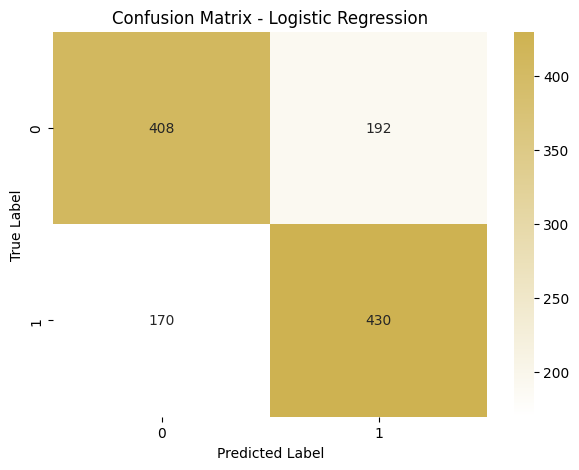

In [ ]:
# Predict on test set
y_pred = log_clf.predict(X_test)

# Classification report
print("Classification Report: Logistic Regression\n")
print(classification_report(y_test, y_pred))
CMAP_Color  = LinearSegmentedColormap.from_list("custom_acc",  ["#ffffff", "#ceb251"])

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_Color,
            xticklabels=y_test.unique(),
            yticklabels=y_test.unique())
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Learning Curve Visualization

This cell draws two learning curve charts side by side for a Logistic Regression classifier wrapped in a Pipeline with StandardScaler.
Both charts use stratified k fold cross validation and the same train sizes.
Left chart uses accuracy. Right chart uses F1 macro.
Comparing the two helps diagnose underfitting or overfitting by inspecting the gap between training and validation scores as data grows.

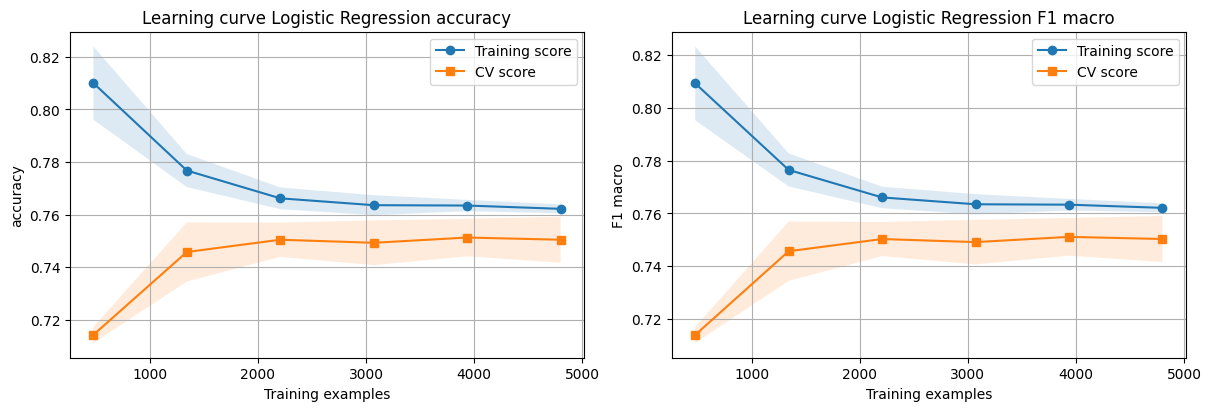

Accuracy validation means: [0.714 0.746 0.75  0.749 0.751 0.75 ]
F1 macro validation means: [0.714 0.746 0.75  0.749 0.751 0.75 ]


In [ ]:
# Build the classifier inside a pipeline to include feature scaling
log_est = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    # Uncomment the next line if classes are highly imbalanced
    # class_weight="balanced",
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", log_est),
])

# Use stratified folds to keep class proportions consistent in every split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use the same train sizes for both metrics
train_sizes = np.linspace(0.1, 1.0, 6)

def compute_curve(scoring):
    """Compute learning curve arrays for a given scoring metric."""
    ts, train_scores, valid_scores, fit_times, _ = learning_curve(
        estimator=pipe,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_times=True,
        shuffle=True,
        random_state=42,
    )
    return ts, train_scores.mean(axis=1), train_scores.std(axis=1), \
           valid_scores.mean(axis=1), valid_scores.std(axis=1), \
           fit_times.mean(axis=1)

# Compute both metrics
acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std, acc_fit = compute_curve("accuracy")
f1_ts,  f1_tr_mean,  f1_tr_std,  f1_va_mean,  f1_va_std,  f1_fit  = compute_curve("f1_macro")

# Plot two charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_mean, tr_std, va_mean, va_std, title, y_label):
    """Draw a single learning curve with shaded variability."""
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
    ax.fill_between(ts, va_mean - va_std, va_mean + va_std, alpha=0.15)
    ax.plot(ts, tr_mean, marker="o", label="Training score")
    ax.plot(ts, va_mean, marker="s", label="CV score")
    ax.grid(True)
    ax.legend()

plot_curve(axes[0], acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std,
           "Learning curve Logistic Regression accuracy", "accuracy")

plot_curve(axes[1], f1_ts, f1_tr_mean, f1_tr_std, f1_va_mean, f1_va_std,
           "Learning curve Logistic Regression F1 macro", "F1 macro")

plt.show()

# Optional quick summary
print("Accuracy validation means:", np.round(acc_va_mean, 3))
print("F1 macro validation means:", np.round(f1_va_mean, 3))

### **Method 2: Random Forest (Bagging)**

#### Model Training

This cell creates and trains a Random Forest classifier for multi-class dialect recognition.
The model constructs multiple decision trees on random feature subsets and aggregates their predictions to improve robustness and reduce overfitting. The out-of-bag (OOB) score provides an internal unbiased estimate of model performance during training.

In [ ]:
# Create and train the Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

# Train the model
rf_clf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced_subsample', n_estimators=300,
                       n_jobs=-1, oob_score=True, random_state=42)

#### Hyperparameter Tuning

Model hyperparameters are optimized to enhance predictive accuracy and generalization.
This cell defines a grid of candidate parameters for n_estimators, max_depth, and min_samples_split, and employs GridSearchCV with 5-fold cross-validation to identify the configuration that achieves the highest validation performance.

In [ ]:
# Define hyperparameter distributions for random search
param_distributions = {
    'n_estimators': randint(100, 401),      # random int between 100 and 400
    'max_depth': [None, 10, 20, 30],        # try a few depths + no limit
    'max_features': ['sqrt'],               # keep as before
    'min_samples_split': randint(2, 11),    # 2–10
    'min_samples_leaf': randint(1, 5),      # 1–4
    'bootstrap': [True],
    'class_weight': [None, 'balanced_subsample']
}

# Random search with cross-validation
random_search = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42),
    param_distributions=param_distributions,
    n_iter=20,              # how many random combinations to try
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    refit=True,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

# Keep the tuned model for evaluation
best_rf = random_search.best_estimator_



Best Parameters: {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 352}


#### Cross Validation

This cell performs a 5-fold Stratified Cross-Validation on the baseline Random Forest model to evaluate stability before hyperparameter tuning.
Each fold preserves balanced dialect class proportions, and the mean accuracy across folds is recorded to assess overall consistency and bias–variance behavior.

In [ ]:
# 5-fold CV on the baseline RF (pre-tuning)
cv_scores = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy per fold:", np.round(cv_scores, 4))
print("Mean CV Accuracy:", cv_scores.mean())


Cross-Validation Accuracy per fold: [0.7823 0.7698 0.8146 0.7969 0.7789]
Mean CV Accuracy: 0.788495611748349


#### Evaluation and Results

This cell evaluates the tuned Random Forest model on the unseen test set to measure performance.
Predictions are compared with true labels to compute accuracy, precision, recall, and F1-score, and a confusion matrix is visualized to illustrate dialect classification effectiveness.

Classification Report: Random Forest (Bagging)

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       600
           1       0.75      0.79      0.77       600

    accuracy                           0.77      1200
   macro avg       0.77      0.77      0.76      1200
weighted avg       0.77      0.77      0.76      1200



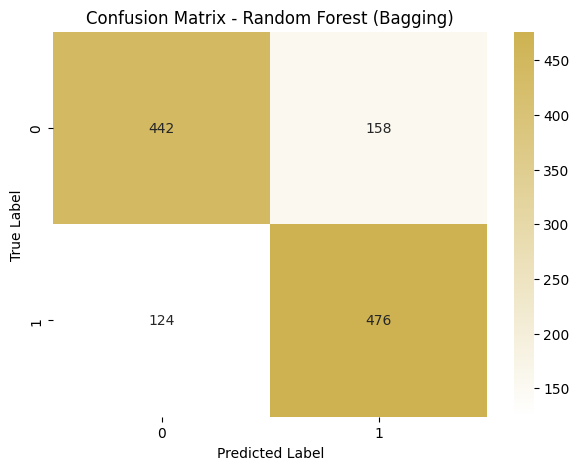

In [ ]:
# Predict on test set using the tuned model
y_pred = best_rf.predict(X_test)

# Classification report
print("Classification Report: Random Forest (Bagging)\n")
print(classification_report(y_test, y_pred))

# Define CMAP_Color (added to resolve NameError)
CMAP_Color  = LinearSegmentedColormap.from_list("custom_acc",  ["#ffffff", "#ceb251"])

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_Color,
            xticklabels=y_test.unique(),
            yticklabels=y_test.unique())
plt.title('Confusion Matrix - Random Forest (Bagging)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Learning Curve Visualization


This cell draws two learning curve charts side by side for a Random Forest classifier to analyze model scalability and generalization.
Both charts use stratified k-fold cross validation and identical training sizes.
Left chart shows accuracy, right chart shows F1 macro.
Comparing the two helps detect overfitting or underfitting by observing the convergence of training and validation scores as the sample size increases.

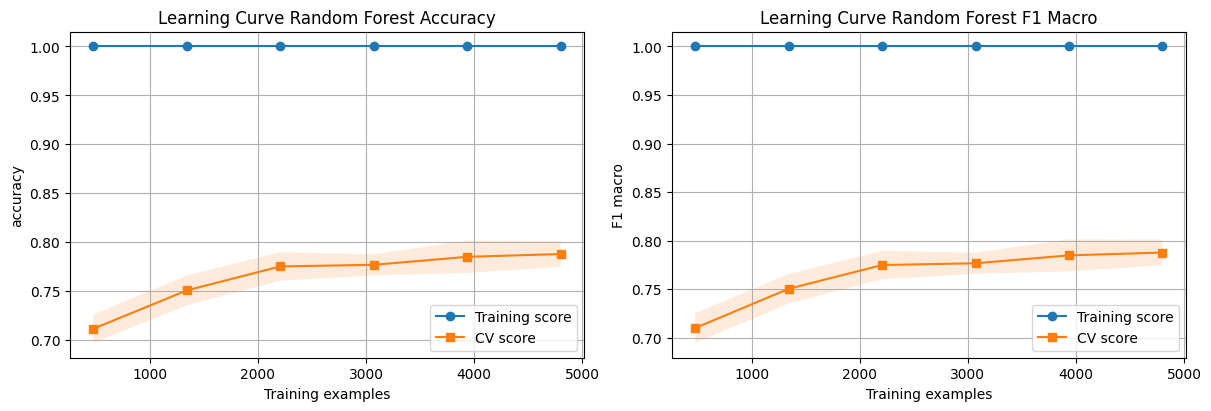

Accuracy validation means: [0.711 0.751 0.775 0.777 0.785 0.788]
F1 macro validation means: [0.71  0.75  0.775 0.777 0.785 0.788]


In [ ]:
# Build the classifier inside a pipeline to include feature scaling
rf_est = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

def compute_curve(estimator, scoring):
    """Compute learning curve arrays for a given metric."""
    ts, train_scores, valid_scores, fit_times, _ = learning_curve(
        estimator=estimator,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_times=True,
        shuffle=True,
        random_state=42,
    )
    return ts, train_scores.mean(axis=1), train_scores.std(axis=1), \
           valid_scores.mean(axis=1), valid_scores.std(axis=1)

# Compute both metrics
acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std = compute_curve(rf_est, "accuracy")
f1_ts,  f1_tr_mean,  f1_tr_std,  f1_va_mean,  f1_va_std = compute_curve(rf_est, "f1_macro")

# Plot two charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_mean, tr_std, va_mean, va_std, title, ylabel):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(ylabel)
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
    ax.fill_between(ts, va_mean - va_std, va_mean + va_std, alpha=0.15)
    ax.plot(ts, tr_mean, marker="o", label="Training score")
    ax.plot(ts, va_mean, marker="s", label="CV score")
    ax.legend()
    ax.grid(True)

plot_curve(axes[0], acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std,
           "Learning Curve Random Forest Accuracy", "accuracy")

plot_curve(axes[1], f1_ts, f1_tr_mean, f1_tr_std, f1_va_mean, f1_va_std,
           "Learning Curve Random Forest F1 Macro", "F1 macro")

plt.show()

print("Accuracy validation means:", np.round(acc_va_mean, 3))
print("F1 macro validation means:", np.round(f1_va_mean, 3))

### **Method 3: AdaBoost (Boosting)**

#### Model Training

This cell creates and trains an AdaBoost model using a Decision Tree as the base learner.
The model learns from the training data by combining several weak learners (small decision trees) into one stronger model.
 Parameters like n_estimators and learning_rate control how many weak models are built and how much each one contributes.

In [ ]:
# Initialize AdaBoost with Decision Tree as the base estimator
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Train the AdaBoost model
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=100, random_state=42)

#### Hyperparameter Tuning

Model hyperparameters are optimized to enhance predictive accuracy and generalization.

This cell defines a grid of hyperparameters, such as the number of estimators, learning rate, and decision tree depth to find the combination that gives the best cross-validation accuracy.

In [ ]:
# Define hyperparameter distributions for AdaBoost
param_distributions = {
    'n_estimators': randint(50, 301),       # random int between 50 and 300
    'learning_rate': uniform(0.01, 1.0),    # continuous range 0.01–1.01
    'estimator__max_depth': randint(1, 6)   # depth between 1–5
}

# Random search with cross-validation
random_search = RandomizedSearchCV(
    estimator=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    param_distributions=param_distributions,
    n_iter=20,          # number of random configs to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit the tuner
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

# Keep best model
best_ada = random_search.best_estimator_


Best Parameters: {'estimator__max_depth': 5, 'learning_rate': np.float64(0.6111150117432088), 'n_estimators': 201}


#### Cross Validation

This part evaluates the AdaBoost model’s reliability using 5-fold Stratified Cross-Validation. It splits the training data into five folds, trains on four, and validates on the fifth. The printed mean accuracy shows how consistently the model performs across different subsets of dialect samples.

In [ ]:
cv_scores = cross_val_score(ada_clf, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy per fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Accuracy per fold: [0.790625   0.77395833 0.79479167 0.78125    0.75599583]
Mean CV Accuracy: 0.7793241657977059


#### Evaluation and Results

The trained models are tested on unseen data to measure performance

Accuracy, precision, recall, and F1-score are computed, and results are visualized through confusion matrices and comparative charts illustrating dialect recognition effectiveness.

Classification Report: AdaBoost

              precision    recall  f1-score   support

           0       0.74      0.71      0.72       600
           1       0.72      0.75      0.73       600

    accuracy                           0.73      1200
   macro avg       0.73      0.73      0.73      1200
weighted avg       0.73      0.73      0.73      1200



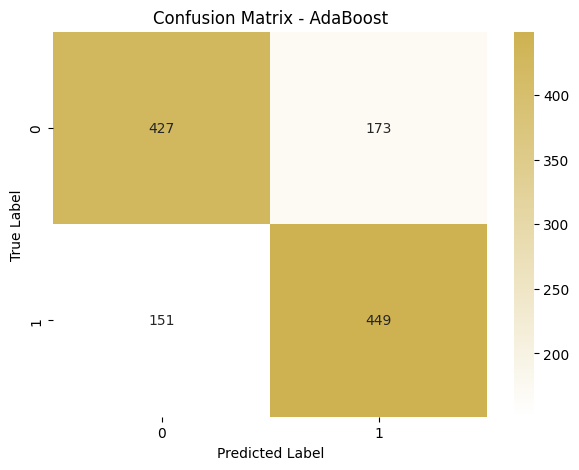

In [ ]:
# Predict on test set
y_pred = ada_clf.predict(X_test)

# Classification report
print("Classification Report: AdaBoost\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_Color,
            xticklabels=y_test.unique(),
            yticklabels=y_test.unique())
plt.title('Confusion Matrix - AdaBoost')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


#### Learning Curve Visualization


This cell draws two learning curve charts side by side for an AdaBoost classifier using a Decision Tree as the base estimator.
Both charts use stratified k-fold cross validation and identical training sizes.
The left chart shows accuracy, while the right chart shows F1-macro.
Comparing the two helps evaluate the ensemble’s learning progress and detect potential underfitting or overfitting as the training data increases.

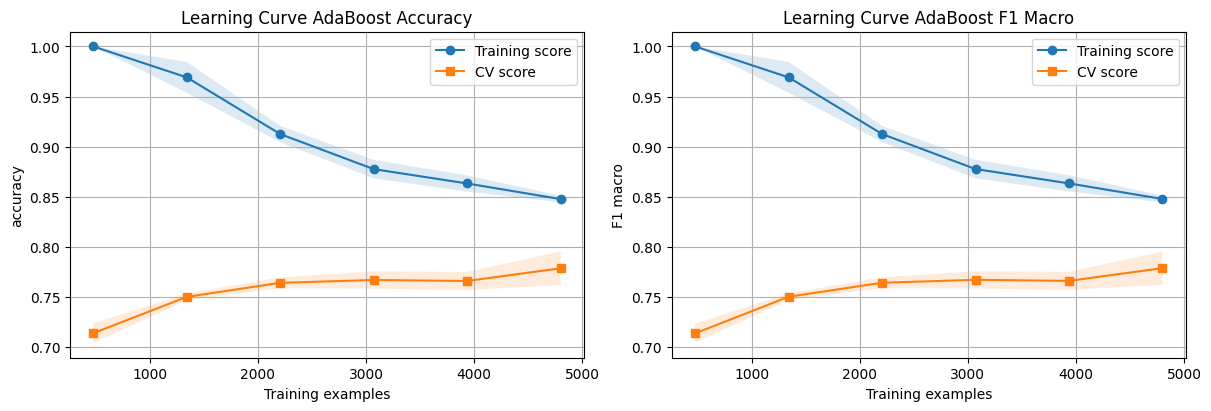

Accuracy validation means: [0.714 0.75  0.764 0.767 0.766 0.779]
F1-macro validation means: [0.714 0.75  0.764 0.767 0.766 0.779]


In [ ]:
# Initialize the tuned AdaBoost model (Decision Tree base)
ada_est = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# Stratified 5-fold CV and training size fractions
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

def compute_curve(estimator, scoring):
    """Compute learning curve values for the given metric."""
    ts, train_scores, valid_scores, fit_times, _ = learning_curve(
        estimator=estimator,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_times=True,
        shuffle=True,
        random_state=42
    )
    # Return mean and std for plotting
    return (
        ts,
        train_scores.mean(axis=1), train_scores.std(axis=1),
        valid_scores.mean(axis=1), valid_scores.std(axis=1),
        fit_times.mean(axis=1)
    )

# Compute learning curves for Accuracy and F1-macro
acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std, acc_fit = compute_curve(ada_est, "accuracy")
f1_ts,  f1_tr_mean,  f1_tr_std,  f1_va_mean,  f1_va_std,  f1_fit  = compute_curve(ada_est, "f1_macro")

# Create two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_mean, tr_std, va_mean, va_std, title, y_label):
    """Plot one learning curve with shaded variability bands."""
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    # Shaded area = ±1 standard deviation
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15)
    ax.fill_between(ts, va_mean - va_std, va_mean + va_std, alpha=0.15)
    # Main curves
    ax.plot(ts, tr_mean, marker="o", label="Training score")
    ax.plot(ts, va_mean, marker="s", label="CV score")
    ax.legend()
    ax.grid(True)

# Plot Accuracy (left) and F1-macro (right)
plot_curve(axes[0], acc_ts, acc_tr_mean, acc_tr_std, acc_va_mean, acc_va_std,
           "Learning Curve AdaBoost Accuracy", "accuracy")

plot_curve(axes[1], f1_ts, f1_tr_mean, f1_tr_std, f1_va_mean, f1_va_std,
           "Learning Curve AdaBoost F1 Macro", "F1 macro")

plt.show()

# Print quick numeric summary
print("Accuracy validation means:", np.round(acc_va_mean, 3))
print("F1-macro validation means:", np.round(f1_va_mean, 3))

### **Method 4: Neural Network**

#### Model Training

This cell creates and trains a Neural Network model using the MLPClassifier (Multi-Layer Perceptron) from scikit-learn.
The model learns non-linear relationships between input features and labels through multiple layers of interconnected neurons.
Parameters such as hidden_layer_sizes, activation, solver, and max_iter control the structure and learning behavior of the network.

In [ ]:
# Initialize Neural Network (MLPClassifier)
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

# Train the Neural Network model
mlp_clf.fit(X_train, y_train)

MLPClassifier(max_iter=300, random_state=42)

#### Hyperparameter Tuning

To enhance performance, key hyperparameters such as the number of neurons, activation function, learning rate, and solver are tuned using GridSearchCV.
This process evaluates multiple combinations to find the configuration that yields the best cross-validation accuracy

In [ ]:
# Define hyperparameter distributions
param_distributions = {
    # keep a small set of good layer configs
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    # sample learning rate in a range
    'learning_rate_init': uniform(1e-4, 1e-2),   # 0.0001 to 0.0101
    # sample max_iter between 200 and 600
    'max_iter': randint(200, 601)
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=20,                # number of random combinations to try
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

# Best tuned model
best_mlp = random_search.best_estimator_



Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (100, 50), 'learning_rate_init': np.float64(0.009932308858067881), 'max_iter': 330, 'solver': 'adam'}


#### Cross Validation

This step evaluates the Neural Network model’s reliability using 5-fold Stratified Cross-Validation.
The training data is split into five folds — four used for training and one for validation in each iteration.
The mean accuracy across all folds reflects how well the model generalizes.

In [ ]:
cv_scores = cross_val_score(mlp_clf, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy per fold:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-Validation Accuracy per fold: [0.54270833 0.51666667 0.56354167 0.53020833 0.5641293 ]
Mean CV Accuracy: 0.5434508602711158


#### Evaluation and Results

After tuning and validation, the optimized model is tested on unseen data (X_test).
Performance metrics such as precision, recall, and F1-score are reported, and a confusion matrix visualizes the classification results.

Classification Report: Neural Network (MLPClassifier)

              precision    recall  f1-score   support

           0       0.76      0.54      0.63       600
           1       0.64      0.83      0.73       600

    accuracy                           0.69      1200
   macro avg       0.70      0.69      0.68      1200
weighted avg       0.70      0.69      0.68      1200



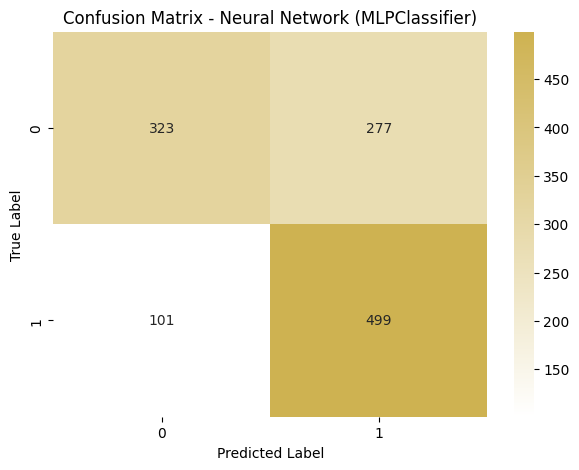

In [ ]:
# Predict on test data
y_pred = mlp_clf.predict(X_test)

# Print classification report
print("Classification Report: Neural Network (MLPClassifier)\n")
print(classification_report(y_test, y_pred))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_Color,
            xticklabels=y_test.unique(),
            yticklabels=y_test.unique())
plt.title('Confusion Matrix - Neural Network (MLPClassifier)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Learning Curve Visualization


This cell draws two learning curve charts side by side for a Neural Network classifier using MLPClassifier.
Both charts use stratified k fold cross validation and identical training sizes.
The left chart shows accuracy and the right chart shows F1 macro.
Comparing the two helps diagnose underfitting or overfitting by observing the gap between training and validation scores as data grows.

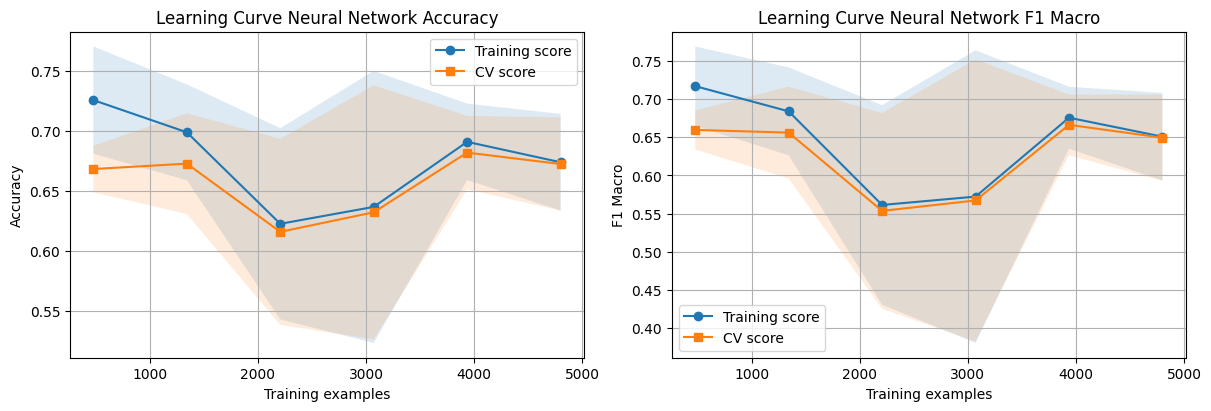

Accuracy validation means: [0.668 0.673 0.616 0.632 0.682 0.672]
F1 macro validation means: [0.66  0.656 0.553 0.567 0.666 0.649]


In [ ]:
# Learning curves for Neural Network (MLP) — clean style, robust y handling

# Recover a proper 1D target vector aligned with X
def _to_1d(a):
    if a is None: return None
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    a = np.asarray(a)
    if a.ndim == 1: return a
    if a.ndim == 2 and a.shape[1] == 1: return a.ravel()
    return None

def _stack_rows(a, b):
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    if hasattr(b, "to_numpy"): b = b.to_numpy()
    return np.vstack([a, b])

def _stack_cols(a, b):
    a = _to_1d(a); b = _to_1d(b)
    return np.concatenate([a, b], axis=0)

# Prefer full X/y if present; otherwise reconstruct from splits
X_used = X
y_all = _to_1d(globals().get("y", None))
if (y_all is None) or (hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]):
    y_tr = _to_1d(globals().get("y_train", None))
    y_te = _to_1d(globals().get("y_test", None))
    X_tr = globals().get("X_train", None)
    X_te = globals().get("X_test", None)
    if y_tr is not None and y_te is not None:
        y_all = _stack_cols(y_tr, y_te)
        if X_tr is not None and X_te is not None:
            X_used = _stack_rows(X_tr, X_te)

# Final checks
if y_all is None:
    raise ValueError("Could not recover y_all. Ensure you have `y` or both (`y_train`,`y_test`).")
if hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]:
    raise ValueError(f"X/y length mismatch: X rows={X_used.shape[0]}, y len={len(y_all)}.")

# CV setup and train-size grid
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

def compute_curve(estimator, scoring):
    """Compute learning curve arrays for the given metric."""
    ts, tr, va, fit_times, _ = learning_curve(
        estimator=estimator,
        X=X_used, y=y_all,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_times=True,
        shuffle=True,
        random_state=42
    )
    return (
        ts,
        tr.mean(axis=1), tr.std(axis=1),
        va.mean(axis=1), va.std(axis=1),
        fit_times.mean(axis=1)
    )

# Curves for Accuracy and F1 macro using your MLP model
acc_ts, acc_tr_m, acc_tr_s, acc_va_m, acc_va_s, acc_fit = compute_curve(mlp_clf, "accuracy")
f1_ts,  f1_tr_m,  f1_tr_s,  f1_va_m,  f1_va_s,  f1_fit  = compute_curve(mlp_clf, "f1_macro")

# Plot two charts side by side (default colors, no shading)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_m, tr_s, va_m, va_s, title, y_label):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    ax.fill_between(ts, va_m - va_s, va_m + va_s, alpha=0.15)
    ax.plot(ts, tr_m, marker="o", label="Training score")
    ax.plot(ts, va_m, marker="s", label="CV score")
    ax.grid(True)
    ax.legend()

plot_curve(axes[0], acc_ts, acc_tr_m, acc_tr_s, acc_va_m, acc_va_s,
           "Learning Curve Neural Network Accuracy", "Accuracy")

plot_curve(axes[1], f1_ts, f1_tr_m, f1_tr_s, f1_va_m, f1_va_s,
           "Learning Curve Neural Network F1 Macro", "F1 Macro")

plt.show()

# Quick numeric summary
print("Accuracy validation means:", np.round(acc_va_m, 3))
print("F1 macro validation means:", np.round(f1_va_m, 3))

###**Method 5: RNN**





#### Model Training

This method applies a Recurrent Neural Network (RNN) to dialect classification.  
Unlike traditional models that treat each sample as a flat feature vector, an RNN processes inputs as ordered sequences, making it suitable for capturing temporal patterns in audio features. Each feature vector is reshaped into a sequence and fed to a SimpleRNN layer, followed by dense layers that output the predicted dialect class.

In [ ]:

# ====== Prepare data for RNN (reshape to 3D: samples, timesteps, features) ======
# Here we treat each feature as a time step with 1 feature per step.
# Adapt if you already have a different RNN input shape.
X_train_rnn = X_train.to_numpy().reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_rnn  = X_test.to_numpy().reshape(X_test.shape[0],  X_test.shape[1],  1)

# y_train and y_test should already be encoded as 0 (Not Gulf) / 1 (Gulf)
y_train_np = y_train.astype("float32").to_numpy() # Convert y_train to a NumPy array
y_test_np  = y_test.astype("float32").to_numpy()  # Convert y_test to a NumPy array

# ====== Build a baseline RNN model ======
def build_rnn_model(units=64, dropout_rate=0.3, learning_rate=1e-3):
    model = Sequential([
        SimpleRNN(units, input_shape=(X_train_rnn.shape[1], 1), return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # single neuron for binary classification
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',          # <- binary loss for 0/1 labels
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

rnn_model = build_rnn_model()

# Early stopping to prevent overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ====== Train the RNN model ======
history_rnn = rnn_model.fit(
    X_train_rnn, y_train_np,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### Hyperparameter Tuning




To improve performance, key RNN hyperparameters such as the number of recurrent
units, dropout rate, and learning rate are tuned using `RandomizedSearchCV`.
A Keras wrapper is used so that the RNN model can be treated like a scikit-learn
estimator, allowing randomized search over a defined hyperparameter space with
cross-validation.

In [ ]:
# Define a small set of hyperparameter combinations to try
rnn_param_grid = [
    {"units": 32, "dropout_rate": 0.2, "learning_rate": 1e-3},
    {"units": 64, "dropout_rate": 0.3, "learning_rate": 1e-3},
    {"units": 64, "dropout_rate": 0.4, "learning_rate": 5e-4},
    {"units": 128, "dropout_rate": 0.3, "learning_rate": 1e-3},
]

best_val_acc = -np.inf
best_params = None
best_rnn_model = None

for params in rnn_param_grid:
    print("\nTrying params:", params)
    model = build_rnn_model(
        units=params["units"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"]
    )

    history = model.fit(
        X_train_rnn, y_train,
        validation_split=0.2,
        epochs=25,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # Take best validation accuracy achieved during training
    val_acc = max(history.history["val_accuracy"])
    print(f"Best val_accuracy for this run: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_rnn_model = model

print("\nBest Parameters for RNN:", best_params)
print("Best Validation Accuracy:", best_val_acc)



Trying params: {'units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001}
Best val_accuracy for this run: 0.6271

Trying params: {'units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001}
Best val_accuracy for this run: 0.6229

Trying params: {'units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0005}
Best val_accuracy for this run: 0.6375

Trying params: {'units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}
Best val_accuracy for this run: 0.6000

Best Parameters for RNN: {'units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0005}
Best Validation Accuracy: 0.637499988079071


#### Cross Validation

To evaluate the robustness of the RNN model, 5-fold Stratified Cross-Validation is
performed on the training set. In each fold, the model is trained on 4/5 of the data
and validated on the remaining 1/5, preserving the proportion of Gulf (1) and
Not Gulf (0) samples. The mean cross-validation accuracy summarizes how well the
RNN generalizes across different splits of the data.


In [ ]:
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold = 1
for train_idx, val_idx in skf.split(X_train_rnn, y_train_np):
    print(f"\nFold {fold}")
    X_tr, X_val = X_train_rnn[train_idx], X_train_rnn[val_idx]
    y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]

    model = build_rnn_model()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    loss, acc, prec, rec = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Accuracy: {acc:.4f}")
    cv_scores.append(acc)
    fold += 1

print("\nCross-Validation Accuracy per fold:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))


Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Validation Accuracy: 0.6583

Fold 2
Validation Accuracy: 0.6229

Fold 3
Validation Accuracy: 0.6344

Fold 4
Validation Accuracy: 0.6125

Fold 5
Validation Accuracy: 0.5714

Cross-Validation Accuracy per fold: [0.6583333611488342, 0.6229166388511658, 0.6343749761581421, 0.612500011920929, 0.5714285969734192]
Mean CV Accuracy: 0.619910717010498


#### Evaluation and Results

After selecting the best hyperparameters, the optimized RNN model is evaluated on
the unseen test set (`X_test_rnn`). Performance metrics such as accuracy, precision,
recall, and F1-score are reported, and a confusion matrix illustrates the distribution
of correct and incorrect predictions.

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Classification Report: Recurrent Neural Network (RNN)

              precision    recall  f1-score   support

    Not Gulf       0.61      0.64      0.62       600
        Gulf       0.62      0.60      0.61       600

    accuracy                           0.62      1200
   macro avg       0.62      0.62      0.62      1200
weighted avg       0.62      0.62      0.62      1200



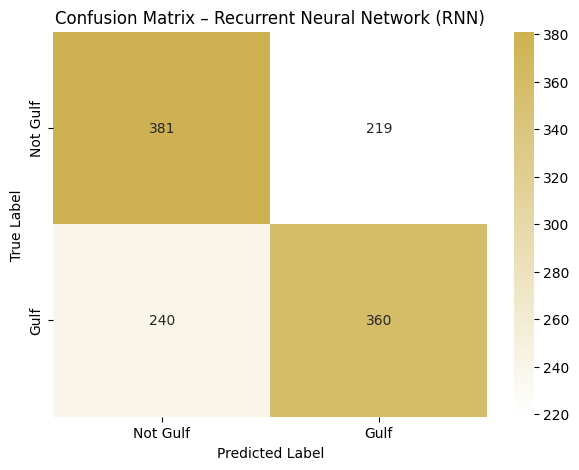

In [ ]:
# Predict probabilities on the test set
y_proba_rnn = best_rnn_model.predict(X_test_rnn).ravel()

# Convert to class labels
y_pred_rnn = (y_proba_rnn >= 0.5).astype(int)

# Classification report
print("Classification Report: Recurrent Neural Network (RNN)\n")
print(classification_report(
    y_test,
    y_pred_rnn,
    target_names=["Not Gulf", "Gulf"]
))

# -------- CUSTOM COLORMAP -------- #
CMAP_Color = LinearSegmentedColormap.from_list(
    "custom_acc", ["#ffffff", "#ceb251"]
)

# Confusion matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rnn,
    annot=True,
    fmt='d',
    cmap=CMAP_Color,
    xticklabels=["Not Gulf", "Gulf"],
    yticklabels=["Not Gulf", "Gulf"]
)

plt.title("Confusion Matrix – Recurrent Neural Network (RNN)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()





#### Learning Curve Visualization


This code cell trains the RNN on increasing subset sizes and plots its learning curves. It shows how training and validation accuracy and F1-macro change as more data is used. The printed arrays summarize the mean validation scores for each subset size.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

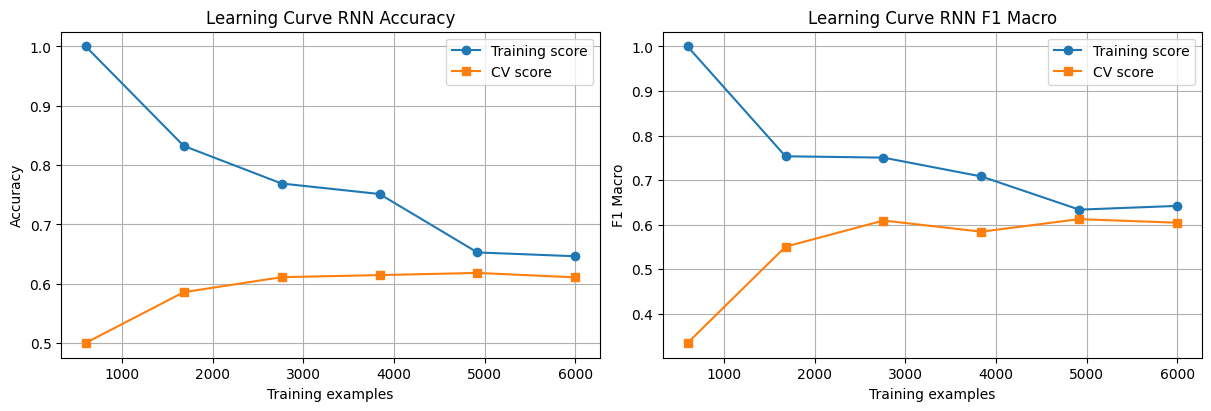

RNN Accuracy validation means: [0.5   0.586 0.611 0.614 0.618 0.611]
RNN F1 macro validation means: [0.334 0.55  0.609 0.584 0.612 0.604]


In [ ]:
# ==========================================================
# Learning Curves for RNN (Accuracy + F1 Macro)
# ==========================================================

from sklearn.metrics import f1_score # Added import for f1_score
from tensorflow.keras.layers import Input # Import Input layer

# Convert full X/y into RNN 3D format
X_used_rnn = X.to_numpy().reshape(X.shape[0], X.shape[1], 1)
y_used_rnn = y.astype("float32").to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

# RNN builder
def build_rnn_for_curve():
    model = Sequential([
        Input(shape=(X_used_rnn.shape[1], 1)), # Recommended way to define input shape
        SimpleRNN(64, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Compute BOTH Accuracy + F1 learning curves manually
def compute_rnn_curve(metric="accuracy"):
    train_scores = []
    val_scores   = []
    fit_times    = []
    sizes_list   = []

    for ts in train_sizes:
        n_train = int(len(X_used_rnn) * ts)
        sizes_list.append(n_train)

        fold_train = []
        fold_val   = []
        fold_times = []

        for train_idx, val_idx in cv.split(X_used_rnn, y_used_rnn):

            tr_idx = train_idx[:n_train]
            X_tr, y_tr = X_used_rnn[tr_idx], y_used_rnn[tr_idx]
            X_val, y_val = X_used_rnn[val_idx], y_used_rnn[val_idx]

            model = build_rnn_for_curve()

            start = time.time()
            model.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=12,
                batch_size=32,
                verbose=0
            )
            end = time.time()

            # Training metric
            y_tr_pred = (model.predict(X_tr, verbose=0).ravel() >= 0.5).astype(int)
            if metric == "accuracy":
                fold_train.append(accuracy_score(y_tr, y_tr_pred))
            else:
                fold_train.append(f1_score(y_tr, y_tr_pred, average="macro"))

            # Validation metric
            y_val_pred = (model.predict(X_val, verbose=0).ravel() >= 0.5).astype(int)
            if metric == "accuracy":
                fold_val.append(accuracy_score(y_val, y_val_pred))
            else:
                fold_val.append(f1_score(y_val, y_val_pred, average="macro"))

            fold_times.append(end - start)

        train_scores.append(np.mean(fold_train))
        val_scores.append(np.mean(fold_val))
        fit_times.append(np.mean(fold_times))

    return (
        np.array(sizes_list),
        np.array(train_scores),
        np.array(val_scores),
        np.array(fit_times)
    )


# Compute both metrics
acc_sizes, acc_tr, acc_va, acc_time = compute_rnn_curve(metric="accuracy")
f1_sizes,  f1_tr,  f1_va,  f1_time  = compute_rnn_curve(metric="f1")


# Plotting (same style as your NN code)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, sizes, tr, va, title, y_label):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    ax.fill_between(sizes, tr, tr, alpha=0.15)
    ax.fill_between(sizes, va, va, alpha=0.15)
    ax.plot(sizes, tr, marker="o", label="Training score")
    ax.plot(sizes, va, marker="s", label="CV score")
    ax.grid(True)
    ax.legend()

# Accuracy plot
plot_curve(
    axes[0],
    acc_sizes, acc_tr, acc_va,
    "Learning Curve RNN Accuracy",
    "Accuracy"
)

# F1 Macro plot
plot_curve(
    axes[1],
    f1_sizes, f1_tr, f1_va,
    "Learning Curve RNN F1 Macro",
    "F1 Macro"
)

plt.show()

# Summary
print("RNN Accuracy validation means:", np.round(acc_va, 3))
print("RNN F1 macro validation means:", np.round(f1_va, 3))


###**Method 6: SVM**

####Model Training

This section initializes and trains an SVM classifier using the RBF kernel. The model is configured with class balancing and probability estimation to support multi-class classification. The SVM is trained on the stratified training set, preparing it for later cross-validation and tuning steps.

In [ ]:

from sklearn.svm import SVC

# Create and train the SVM model
svm_clf = SVC(
    kernel='rbf',          # RBF kernel
    C=1.0,                 # Regularization
    gamma='scale',         # Kernel coefficient
    class_weight='balanced',  # Handle class imbalance
    probability=True,      # Enable probability estimation
    random_state=42
)

# Train the model
svm_clf.fit(X_train, y_train)

svm_clf

SVC(class_weight='balanced', probability=True, random_state=42)

#### Hyperparameter Tuning

This section performs hyperparameter optimization using RandomizedSearchCV. A search space is defined for C, gamma, and class weighting, and 5-fold stratified cross-validation is applied to identify the best-performing parameter combination. The best model configuration is then extracted for evaluation.

In [ ]:

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define hyperparameter distributions for random search
param_distributions = {
    'C': np.logspace(-3, 3, 40),                # 0.001 → 1000
    'gamma': ['scale', 'auto'] + list(np.logspace(-4, 1, 20)),
    'kernel': ['rbf'],                          # نحصره على RBF عشان الأداء الأفضل
    'class_weight': [None, 'balanced']
}

# Random search with 5-fold CV
random_search_svm = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_distributions=param_distributions,
    n_iter=40,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit search
random_search_svm.fit(X_train, y_train)

print("Best Parameters:", random_search_svm.best_params_)

# Keep the tuned model
best_svm = random_search_svm.best_estimator_


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Parameters: {'kernel': 'rbf', 'gamma': np.float64(0.00018329807108324357), 'class_weight': 'balanced', 'C': np.float64(7.01703828670383)}


####Cross-Validation

A 5-fold stratified cross-validation is run on the baseline SVM model to assess consistency and generalization across different data splits. The mean CV accuracy reflects the model’s stability before testing on unseen data.

In [ ]:


from sklearn.model_selection import cross_val_score

# 5-fold cross validation on the baseline SVM model
cv_scores_svm = cross_val_score(
    svm_clf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-Validation Accuracy per fold:", np.round(cv_scores_svm, 4))
print("Mean CV Accuracy:", cv_scores_svm.mean())


Cross-Validation Accuracy per fold: [0.6146 0.6365 0.6604 0.6198 0.6611]
Mean CV Accuracy: 0.6384710636079249


####Evaluation and Results

The tuned SVM model is evaluated on the unseen test set. Classification performance metrics (precision, recall, F1-score) are computed, and a confusion matrix is visualized to highlight prediction quality across dialect classes using the same color scheme as the Random Forest results.

Classification Report: Support Vector Machine (SVM)

              precision    recall  f1-score   support

           0       0.64      0.67      0.66       600
           1       0.66      0.63      0.64       600

    accuracy                           0.65      1200
   macro avg       0.65      0.65      0.65      1200
weighted avg       0.65      0.65      0.65      1200



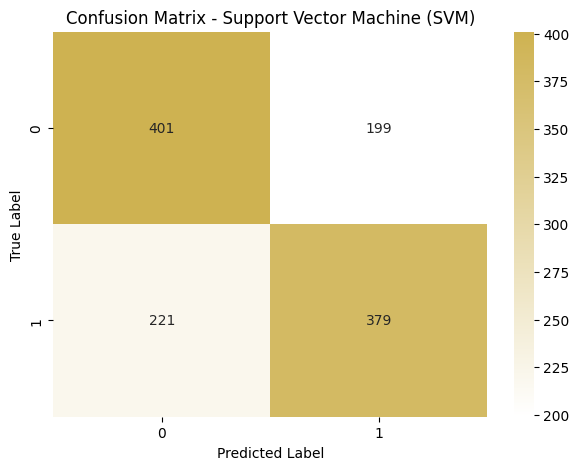

In [ ]:

# Predict on test set using tuned SVM
y_pred = best_svm.predict(X_test)

# Classification report
print("Classification Report: Support Vector Machine (SVM)\n")
print(classification_report(y_test, y_pred))

# Define custom colormap (same style as RF)
CMAP_Color = LinearSegmentedColormap.from_list(
    "custom_acc", ["#ffffff", "#ceb251"]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=CMAP_Color,
    xticklabels=y_test.unique(),
    yticklabels=y_test.unique()
)

plt.title("Confusion Matrix - Support Vector Machine (SVM)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#### Learning Curve Visualization


This code cell generates the SVM learning curves by training the model on increasing amounts of data and plotting both training and validation scores for accuracy and F1-macro. The printed arrays show the mean validation scores for each subset size.

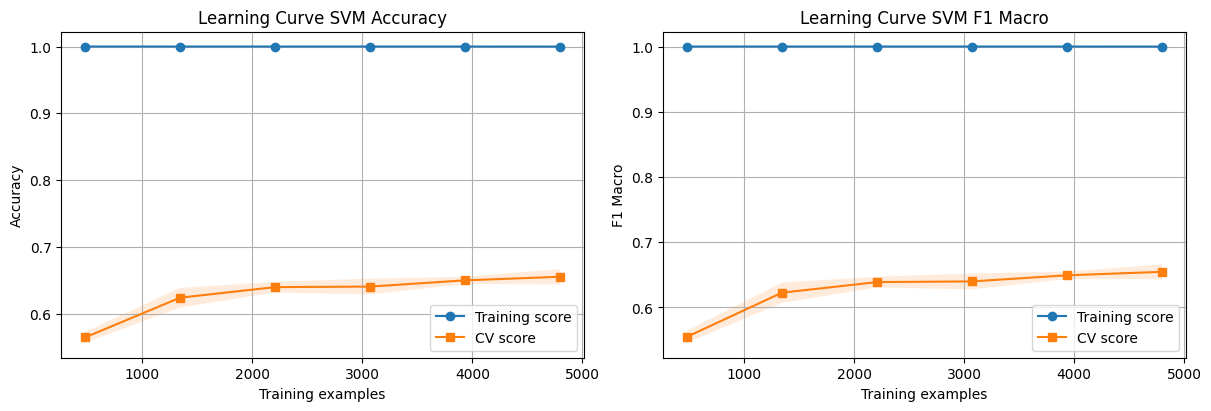

SVM Accuracy validation means: [0.564 0.624 0.64  0.64  0.65  0.655]
SVM F1 macro validation means: [0.555 0.623 0.639 0.64  0.649 0.655]


In [ ]:
# ==========================================================
# Learning Curves for SVM — identical style to MLP learning curves
# ==========================================================

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import learning_curve, StratifiedKFold

# -----------------------------
# Recover a proper 1D y vector
# -----------------------------
def _to_1d(a):
    if a is None: return None
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    a = np.asarray(a)
    if a.ndim == 1: return a
    if a.ndim == 2 and a.shape[1] == 1: return a.ravel()
    return None

def _stack_rows(a, b):
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    if hasattr(b, "to_numpy"): b = b.to_numpy()
    return np.vstack([a, b])

def _stack_cols(a, b):
    a = _to_1d(a); b = _to_1d(b)
    return np.concatenate([a, b], axis=0)

# Prefer full X/y if available
X_used = X
y_all = _to_1d(globals().get("y", None))

if (y_all is None) or (hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]):
    y_tr = _to_1d(globals().get("y_train", None))
    y_te = _to_1d(globals().get("y_test", None))
    X_tr = globals().get("X_train", None)
    X_te = globals().get("X_test", None)

    if y_tr is not None and y_te is not None:
        y_all = _stack_cols(y_tr, y_te)
        if X_tr is not None and X_te is not None:
            X_used = _stack_rows(X_tr, X_te)

# Final checks
if y_all is None:
    raise ValueError("Could not recover y_all.")
if hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]:
    raise ValueError(f"X/y mismatch: X rows={X_used.shape[0]}, y len={len(y_all)}")

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

# Choose tuned model if available
svm_estimator = best_svm if "best_svm" in globals() else svm_clf

# -----------------------------
# Learning curve computation
# -----------------------------
def compute_curve(estimator, scoring):
    ts, tr, va, fit_times, _ = learning_curve(
        estimator=estimator,
        X=X_used,
        y=y_all,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_times=True,
        shuffle=True,
        random_state=42
    )
    return (
        ts,
        tr.mean(axis=1), tr.std(axis=1),
        va.mean(axis=1), va.std(axis=1),
        fit_times.mean(axis=1)
    )

# Compute Accuracy and F1 macro curves
acc_ts, acc_tr_m, acc_tr_s, acc_va_m, acc_va_s, acc_fit = compute_curve(svm_estimator, "accuracy")
f1_ts,  f1_tr_m,  f1_tr_s,  f1_va_m,  f1_va_s,  f1_fit  = compute_curve(svm_estimator, "f1_macro")

# -----------------------------
# Plot (identical style to MLP)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_m, tr_s, va_m, va_s, title, y_label):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    ax.fill_between(ts, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    ax.fill_between(ts, va_m - va_s, va_m + va_s, alpha=0.15)
    ax.plot(ts, tr_m, marker="o", label="Training score")
    ax.plot(ts, va_m, marker="s", label="CV score")
    ax.grid(True)
    ax.legend()

plot_curve(
    axes[0], acc_ts, acc_tr_m, acc_tr_s, acc_va_m, acc_va_s,
    "Learning Curve SVM Accuracy", "Accuracy"
)

plot_curve(
    axes[1], f1_ts, f1_tr_m, f1_tr_s, f1_va_m, f1_va_s,
    "Learning Curve SVM F1 Macro", "F1 Macro"
)

plt.show()

# Summary numbers
print("SVM Accuracy validation means:", np.round(acc_va_m, 3))
print("SVM F1 macro validation means:", np.round(f1_va_m, 3))

###**Method 7: CNN**

####Data Preparation

This section converts the dataset into NumPy arrays and reshapes the input features into a 3-dimensional format required for 1D-CNN models. The number of features and classes is automatically calculated to ensure compatibility with the CNN architecture.

In [ ]:
# Convert to numpy arrays
X_train_array = np.asarray(X_train)
X_test_array  = np.asarray(X_test)

y_train_array = np.asarray(y_train)
y_test_array  = np.asarray(y_test)

# Number of features
num_features = X_train_array.shape[1]    # مثل (45)

# Number of classes (dialects)
num_classes = len(np.unique(y_train_array))

# Reshape for 1D-CNN
X_train_cnn = X_train_array.reshape(-1, num_features, 1)
X_test_cnn  = X_test_array.reshape(-1, num_features, 1)


####Model Training

This section defines the Convolutional Neural Network (CNN) architecture used for dialect classification. The model consists of two convolutional blocks followed by batch normalization, pooling, and dense layers. The CNN is compiled using the Adam optimizer and trained on the stratified training set with a validation split to monitor learning behavior.

In [ ]:
# ==========================================
# Method 3: Convolutional Neural Network CNN
# ==========================================

## -------------------------
## Model Training
## -------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

def create_cnn_model(
    filters1=64,
    filters2=128,
    dense_units=64,
    dropout_rate=0.5
):
    model = Sequential()

    # 1st Conv block
    model.add(
        Conv1D(
            filters=filters1,
            kernel_size=3,
            activation='relu',
            input_shape=(num_features, 1)
        )
    )
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    # 2nd Conv block
    model.add(
        Conv1D(
            filters=filters2,
            kernel_size=3,
            activation='relu'
        )
    )
    model.add(BatchNormalization())

    # Global pooling + Dense layers
    model.add(GlobalAveragePooling1D())
    model.add(Dropout(dropout_rate))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# إنشاء وتدريب المودل الأساسي (قبل التيوننق)
cnn_model = create_cnn_model()

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_array,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6185 - loss: 0.6345 - val_accuracy: 0.5115 - val_loss: 1.3476
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6826 - loss: 0.5856 - val_accuracy: 0.6146 - val_loss: 0.7222
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6995 - loss: 0.5742 - val_accuracy: 0.6500 - val_loss: 0.6370
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6813 - loss: 0.5812 - val_accuracy: 0.6938 - val_loss: 0.5952
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6910 - loss: 0.5781 - val_accuracy: 0.6802 - val_loss: 0.5932
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6993 - loss: 0.5647 - val_accuracy: 0.6635 - val_loss: 0.5852
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7049 - loss: 0.5594 - val_accuracy: 0.6260 - val_loss: 0.6450
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6924 - loss: 0.5732 - val_accu

Model: "sequential_131"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 55, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_262 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_262 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_263 (Dense)               │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,576 (396.79 KB)

 Trainable params: 33,730 (131.76 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 67,462 (263.53 KB)

####Hyperparameter Tuning

This section evaluates multiple CNN configurations to identify the best-performing architecture. A small grid of candidate combinations is tested by varying convolution filter sizes, dense layer width, and dropout rate. Each configuration is trained on a training subset and validated on a held-out split. The configuration with the highest validation accuracy is selected as the optimal CNN.

In [ ]:
from sklearn.model_selection import train_test_split

# Split training into (train / validation) for tuning
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cnn,
    y_train_array,
    test_size=0.2,
    stratify=y_train_array,
    random_state=42
)

param_grid = [
    {'filters1': 32, 'filters2': 64,  'dense_units': 32,  'dropout_rate': 0.3},
    {'filters1': 64, 'filters2': 128, 'dense_units': 64,  'dropout_rate': 0.5},
    {'filters1': 64, 'filters2': 128, 'dense_units': 128, 'dropout_rate': 0.5},
    {'filters1': 128,'filters2': 256, 'dense_units': 128, 'dropout_rate': 0.5},
]

best_val_acc = 0.0
best_params = None
best_cnn = None

for params in param_grid:
    print(f"Training with params: {params}")

    model = create_cnn_model(
        filters1=params['filters1'],
        filters2=params['filters2'],
        dense_units=params['dense_units'],
        dropout_rate=params['dropout_rate']
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=25,
        batch_size=32,
        verbose=0
    )

    val_acc = max(history.history['val_accuracy'])
    print(f" → Best Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_cnn = model

print("\nBest Parameters:", best_params)
print("Best Validation Accuracy:", best_val_acc)


Training with params: {'filters1': 32, 'filters2': 64, 'dense_units': 32, 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 → Best Val Accuracy: 0.6948
Training with params: {'filters1': 64, 'filters2': 128, 'dense_units': 64, 'dropout_rate': 0.5}
 → Best Val Accuracy: 0.7177
Training with params: {'filters1': 64, 'filters2': 128, 'dense_units': 128, 'dropout_rate': 0.5}
 → Best Val Accuracy: 0.7177
Training with params: {'filters1': 128, 'filters2': 256, 'dense_units': 128, 'dropout_rate': 0.5}
 → Best Val Accuracy: 0.7000

Best Parameters: {'filters1': 64, 'filters2': 128, 'dense_units': 64, 'dropout_rate': 0.5}
Best Validation Accuracy: 0.7177083492279053


####Cross-Validation

To assess generalization consistency, a 5-fold stratified cross-validation is applied using the best CNN configuration from the tuning phase. For each fold, the model is retrained from scratch to avoid bias. Mean accuracy across folds reflects the model’s robustness across different training subsets.

In [ ]:
## -------------------------
## Cross Validation
## -------------------------

from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_cnn = []

fold = 1
for train_idx, val_idx in kfold.split(X_train_cnn, y_train_array):

    # نبني نفس المودل باستخدام أفضل باراميترات من التيوننق
    model = create_cnn_model(
        filters1=best_params['filters1'],
        filters2=best_params['filters2'],
        dense_units=best_params['dense_units'],
        dropout_rate=best_params['dropout_rate']
    )

    X_tr_fold = X_train_cnn[train_idx]
    y_tr_fold = y_train_array[train_idx]
    X_val_fold = X_train_cnn[val_idx]
    y_val_fold = y_train_array[val_idx]

    history = model.fit(
        X_tr_fold, y_tr_fold,
        epochs=25,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Cross-Validation Fold {fold} Accuracy: {acc:.4f}")
    cv_scores_cnn.append(acc)
    fold += 1

print("Mean CV Accuracy:", np.mean(cv_scores_cnn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Cross-Validation Fold 1 Accuracy: 0.5135
Cross-Validation Fold 2 Accuracy: 0.7219
Cross-Validation Fold 3 Accuracy: 0.6302
Cross-Validation Fold 4 Accuracy: 0.7125
Cross-Validation Fold 5 Accuracy: 0.7310
Mean CV Accuracy: 0.6618189454078675


####Evaluation and Results

This section evaluates the tuned CNN model on the unseen test set. Predictions are generated and compared with true labels to compute classification metrics such as precision, recall, and F1-score. A confusion matrix is visualized using a custom color scheme to highlight performance across dialect classes, matching the style used in previous models.

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Classification Report: Convolutional Neural Network (CNN)

              precision    recall  f1-score   support

           0       0.78      0.51      0.62       600
           1       0.64      0.86      0.73       600

    accuracy                           0.69      1200
   macro avg       0.71      0.69      0.68      1200
weighted avg       0.71      0.69      0.68      1200



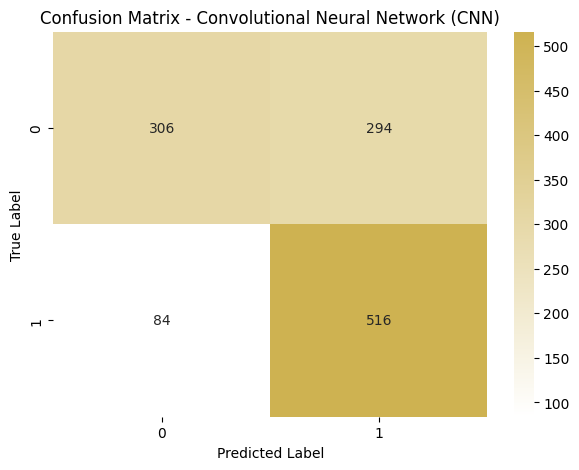

In [ ]:
## -------------------------
## Evaluation and Results
## -------------------------

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# نستخدم best_cnn من التيوننق
y_proba = best_cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_proba, axis=1)

print("Classification Report: Convolutional Neural Network (CNN)\n")
print(classification_report(y_test_array, y_pred_cnn))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test_array, y_pred_cnn)

# نفس الكولور ماب اللي استخدمتيه قبل
CMAP_Color = LinearSegmentedColormap.from_list(
    "custom_acc", ["#ffffff", "#ceb251"]
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap=CMAP_Color,
    xticklabels=np.unique(y_test_array),
    yticklabels=np.unique(y_test_array)
)

plt.title("Confusion Matrix - Convolutional Neural Network (CNN)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


#### Learning Curve Visualization


This code cell produces the CNN learning curves by training the model on progressively larger subsets of the data and plotting training versus validation accuracy and F1-macro. The printed arrays show the mean validation scores for each subset size.

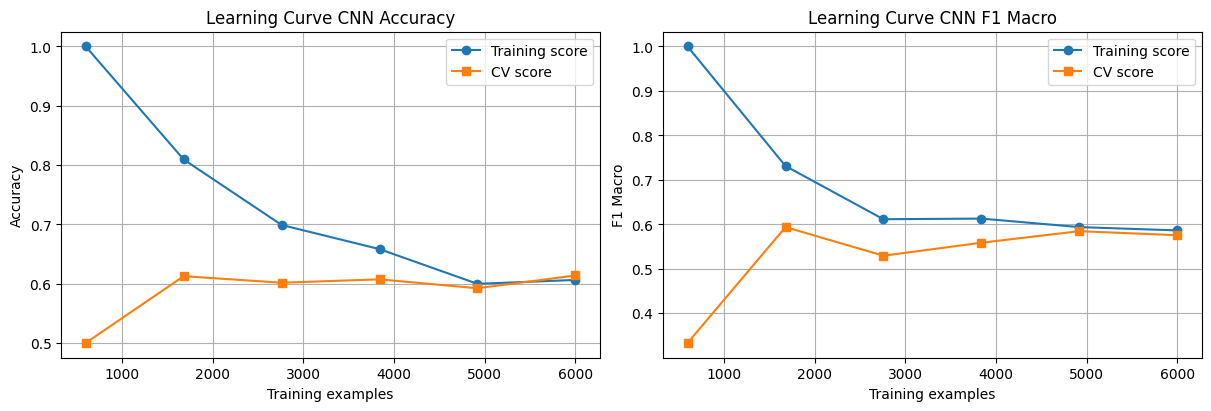

CNN Accuracy validation means: [0.5   0.613 0.602 0.607 0.592 0.614]
CNN F1 macro validation means: [0.333 0.594 0.529 0.559 0.585 0.576]


In [ ]:
# ==========================================================
# Learning Curves for CNN — identical style to MLP learning curves
# ==========================================================

from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.layers import Input

# -----------------------------
# Recover proper 1D y vector
# -----------------------------
def _to_1d(a):
    if a is None: return None
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    a = np.asarray(a)
    if a.ndim == 1: return a
    if a.ndim == 2 and a.shape[1] == 1: return a.ravel()
    return None

def _stack_rows(a, b):
    if hasattr(a, "to_numpy"): a = a.to_numpy()
    if hasattr(b, "to_numpy"): b = b.to_numpy()
    return np.vstack([a, b])

def _stack_cols(a, b):
    a = _to_1d(a); b = _to_1d(b)
    return np.concatenate([a, b], axis=0)

# Prefer full X/y if available
X_used = X
y_all = _to_1d(globals().get("y", None))

if (y_all is None) or (hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]):
    y_tr = _to_1d(globals().get("y_train", None))
    y_te = _to_1d(globals().get("y_test", None))
    X_tr = globals().get("X_train", None)
    X_te = globals().get("X_test", None)

    if y_tr is not None and y_te is not None:
        y_all = _stack_cols(y_tr, y_te)
        if X_tr is not None and X_te is not None:
            X_used = _stack_rows(X_tr, X_te)

# Final checks
if y_all is None:
    raise ValueError("Could not recover y_all.")
if hasattr(X_used, "shape") and len(y_all) != X_used.shape[0]:
    raise ValueError("X/y length mismatch.")

# CNN-ready 3D input
X_used_cnn = X_used.to_numpy().reshape(X_used.shape[0], X_used.shape[1], 1)
num_features = X_used.shape[1]
num_classes = len(np.unique(y_all))

# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 6)

# -----------------------------
# CNN builder for learning curve
# -----------------------------
def build_cnn_for_curve():
    model = Sequential()
    model.add(Input(shape=(num_features, 1)))

    model.add(Conv1D(64, kernel_size=3, activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(128, kernel_size=3, activation="relu"))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# Compute learning curve (manual)
# -----------------------------
def compute_cnn_curve(metric="accuracy"):
    train_scores = []
    val_scores   = []
    fit_times    = []
    sizes_list   = []

    for ts in train_sizes:
        n_train = int(len(X_used_cnn) * ts)
        sizes_list.append(n_train)

        fold_train = []
        fold_val   = []
        fold_times = []

        for train_idx, val_idx in cv.split(X_used_cnn, y_all):

            tr_idx = train_idx[:n_train]
            X_tr, y_tr = X_used_cnn[tr_idx], y_all[tr_idx]
            X_val, y_val = X_used_cnn[val_idx], y_all[val_idx]

            model = build_cnn_for_curve()

            start = time.time()
            model.fit(
                X_tr, y_tr,
                validation_data=(X_val, y_val),
                epochs=8,
                batch_size=32,
                verbose=0
            )
            end = time.time()

            y_tr_pred = np.argmax(model.predict(X_tr, verbose=0), axis=1)
            y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)

            if metric == "accuracy":
                fold_train.append(accuracy_score(y_tr, y_tr_pred))
                fold_val.append(accuracy_score(y_val, y_val_pred))
            else:
                fold_train.append(f1_score(y_tr, y_tr_pred, average="macro"))
                fold_val.append(f1_score(y_val, y_val_pred, average="macro"))

            fold_times.append(end - start)

        train_scores.append(np.mean(fold_train))
        val_scores.append(np.mean(fold_val))
        fit_times.append(np.mean(fold_times))

    return (
        np.array(sizes_list),
        np.array(train_scores),
        np.array(val_scores),
        np.array(fit_times)
    )

# -----------------------------
# Compute both metrics
# -----------------------------
acc_ts, acc_tr_m, acc_va_m, acc_fit = compute_cnn_curve(metric="accuracy")
f1_ts,  f1_tr_m, f1_va_m, f1_fit    = compute_cnn_curve(metric="f1")

# -----------------------------
# Plot — identical style
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

def plot_curve(ax, ts, tr_m, va_m, title, y_label):
    ax.set_title(title)
    ax.set_xlabel("Training examples")
    ax.set_ylabel(y_label)
    ax.fill_between(ts, tr_m, tr_m, alpha=0.15)
    ax.fill_between(ts, va_m, va_m, alpha=0.15)
    ax.plot(ts, tr_m, marker="o", label="Training score")
    ax.plot(ts, va_m, marker="s", label="CV score")
    ax.grid(True)
    ax.legend()

plot_curve(
    axes[0], acc_ts, acc_tr_m, acc_va_m,
    "Learning Curve CNN Accuracy", "Accuracy"
)

plot_curve(
    axes[1], f1_ts, f1_tr_m, f1_va_m,
    "Learning Curve CNN F1 Macro", "F1 Macro"
)

plt.show()

# -----------------------------
# Summary
# -----------------------------
print("CNN Accuracy validation means:", np.round(acc_va_m, 3))
print("CNN F1 macro validation means:", np.round(f1_va_m, 3))

## Final Results

This section compares all trained models side by side on the test set.
For each model, a full classification report is rendered as a formatted table, followed by aggregate comparisons (accuracy, macro-precision, macro-recall, macro-F1).
Charts include grouped bar plots for the macro metrics and a confusion-matrix gallery to visualize error patterns.

### Overall Metrics per Model

This cell computes and displays a summary table of key performance metrics for each trained model on the test set.

The table includes accuracy, macro precision, macro recall, and macro F1, enabling direct side-by-side comparison to identify which models achieve the best balance across evaluation metrics.

In [ ]:
# Summary Table: Calculates and displays overall evaluation metrics (accuracy, precision, recall, F1)
# for each trained model to compare their test performance in a unified table.
def pick(*names):
    """Return the first defined object among the given names."""
    g = globals()
    for n in names:
        if n in g and g[n] is not None:
            return g[n]
    raise NameError(f"None of these models are defined: {names}")

models = {
    "Logistic Regression": pick("log_clf"),
    "Random Forest":       pick("best_rf", "rf_clf"),
    "AdaBoost":            pick("best_ada", "ada_clf"),
    "Neural Network MLP":  pick("mlp_clf"),
    "Support Vector Machine": pick("best_svm", "svm_clf"),
    "Recurrent Neural Network": pick("best_rnn_model", "rnn_model"),
    "Convolutional Neural Network": pick("best_cnn", "cnn_model"),
}

# Collect the overall metrics
overall_rows = []

for name, model in models.items():
    # Handle classical ML vs neural networks
    if name in ["Recurrent Neural Network"]:
        y_pred = (model.predict(X_test_rnn).ravel() >= 0.5).astype(int)

    elif name in ["Convolutional Neural Network"]:
        y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

    else:
        y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    overall_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision macro": p_macro,
        "Recall macro": r_macro,
        "F1 macro": f1_macro,
    })

# Build and display the single comparison table
overall_df = (
    pd.DataFrame(overall_rows)
    .sort_values("F1 macro", ascending=False)
    .reset_index(drop=True)
)


display(
    overall_df
      .style.format(precision=3)
      .set_caption("Overall metrics per model")
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Model,Accuracy,Precision macro,Recall macro,F1 macro
0,AdaBoost,0.766,0.766,0.766,0.766
1,Random Forest,0.765,0.766,0.765,0.765
2,Logistic Regression,0.698,0.699,0.698,0.698
3,Neural Network MLP,0.685,0.702,0.685,0.678
4,Convolutional Neural Network,0.685,0.711,0.685,0.675
5,Support Vector Machine,0.650,0.650,0.650,0.650
6,Recurrent Neural Network,0.618,0.618,0.617,0.617


### Comparative Metrics Chart

This cell generates a comparative bar chart displaying key macro-level performance metrics for all evaluated models.
The grouped bars represent each model’s macro-precision, macro-recall, macro-F1, and accuracy, allowing an easy visual comparison of overall performance and trade-offs between metrics.

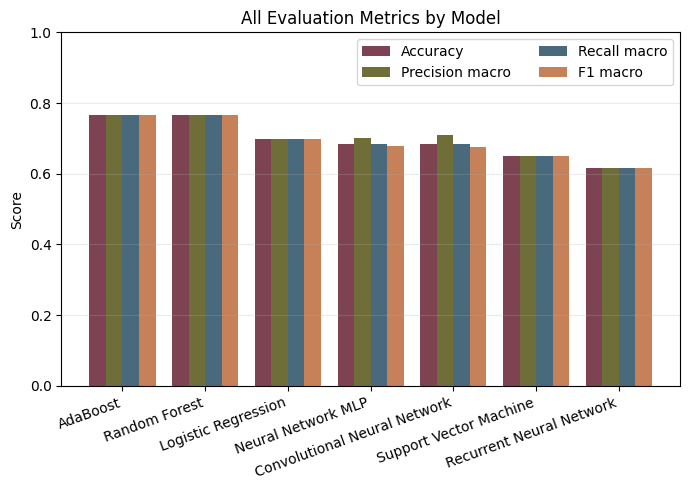

In [ ]:
# Comparative Bar Chart: Visualizes macro-level performance metrics (accuracy, precision, recall, F1)
# across all evaluated models to identify strengths, weaknesses, and overall ranking.

COLORS = {
    "accuracy":        "#7d4352",  # gray crimson
    "precision_macro": "#706e38",  # gray brown
    "recall_macro":    "#49697c",  # gray azure
    "f1_macro":        "#c68159",  # gray orange
}


metrics = ["Accuracy", "Precision macro", "Recall macro", "F1 macro"]
models_order = overall_df["Model"].tolist()
x = np.arange(len(models_order))
width = 0.20

fig, ax = plt.subplots(figsize=(7, 5))

# Bars for each metric
ax.bar(x - 1.5*width, overall_df["Accuracy"],        width, label="Accuracy",        color=COLORS["accuracy"])
ax.bar(x - 0.5*width, overall_df["Precision macro"], width, label="Precision macro", color=COLORS["precision_macro"])
ax.bar(x + 0.5*width, overall_df["Recall macro"],    width, label="Recall macro",    color=COLORS["recall_macro"])
ax.bar(x + 1.5*width, overall_df["F1 macro"],        width, label="F1 macro",        color=COLORS["f1_macro"])

# Axis cosmetics
ax.set_xticks(x)
ax.set_xticklabels(models_order, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("All Evaluation Metrics by Model")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend(ncols=2)  # compact legend

plt.tight_layout()
plt.show()

### Performance Landscape Across Models and Metrics


This cell renders four heatmaps that summarize how each model performs on every class for one metric at a time. Rows list the models and columns list the classes, and each cell shows a score between zero and one with a numeric annotation. The accuracy map here is computed per class and is numerically equal to recall for that class.

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


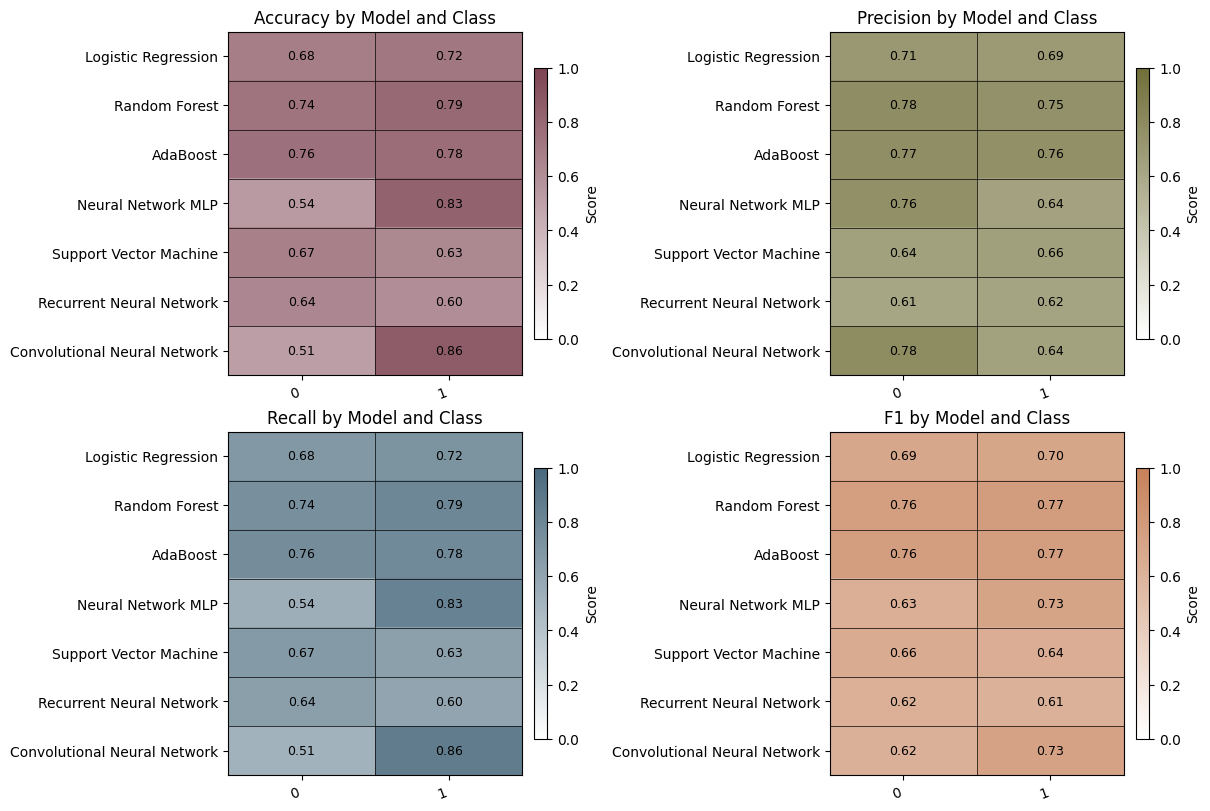

In [ ]:
# Heatmaps for accuracy precision recall and F1 by model and class

# Color settings for each metric heatmap
CMAP_ACCURACY  = LinearSegmentedColormap.from_list("custom_acc",  ["#ffffff", "#7d4352"])
CMAP_PRECISION = LinearSegmentedColormap.from_list("custom_pre",  ["#ffffff", "#706e38"])
CMAP_RECALL    = LinearSegmentedColormap.from_list("custom_rec",  ["#ffffff", "#49697c"])
CMAP_F1        = LinearSegmentedColormap.from_list("custom_f1",   ["#ffffff", "#c68159"])

TEXT_COLOR = "black"
GRID_COLOR = "black"

# Resolve the models dictionary with fallbacks to tuned estimators if present
def pick(*names):
    # Return the first defined estimator or best_estimator_ among the given names
    g = globals()
    for n in names:
        if n in g and g[n] is not None:
            obj = g[n]
            if hasattr(obj, "predict"):
                return obj
            if hasattr(obj, "best_estimator_") and hasattr(obj.best_estimator_, "predict"):
                return obj.best_estimator_
    raise NameError(f"No valid estimator among: {names}")

models = {
    "Logistic Regression":          pick("log_clf", "grid_search_log"),
    "Random Forest":                pick("best_rf", "rf_clf", "grid_search"),
    "AdaBoost":                     pick("best_ada", "ada_clf", "grid_search_ada"),
    "Neural Network MLP":           pick("mlp_clf", "grid_search_mlp"),
    "Support Vector Machine":       pick("best_svm", "svm_clf"),
    "Recurrent Neural Network":     pick("best_rnn_model", "rnn_model"),
    "Convolutional Neural Network": pick("best_cnn", "cnn_model"),
}

# Collect label and model names
labels = sorted(pd.unique(y_test)) if hasattr(pd, "unique") else np.unique(y_test)
model_names = list(models.keys())

# Build empty tables for each metric
acc_tbl = pd.DataFrame(index=model_names, columns=labels, dtype=float)
pre_tbl = pd.DataFrame(index=model_names, columns=labels, dtype=float)
rec_tbl = pd.DataFrame(index=model_names, columns=labels, dtype=float)
f1_tbl  = pd.DataFrame(index=model_names, columns=labels, dtype=float)

# Fill metric tables from per class classification reports
for mname, model in models.items():
    # --- special prediction handling for deep models ---
    if mname == "Recurrent Neural Network":
        y_pred = (model.predict(X_test_rnn).ravel() >= 0.5).astype(int)

    elif mname == "Convolutional Neural Network":
        y_pred = np.argmax(model.predict(X_test_cnn), axis=1)

    else:
        # classical ML (SVM, RF, LR, MLP, AdaBoost)
        y_pred = model.predict(X_test)

    rpt = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    for cls in labels:
        key = str(cls)
        pre_tbl.loc[mname, cls] = rpt.get(key, {}).get("precision", np.nan)
        rec_tbl.loc[mname, cls] = rpt.get(key, {}).get("recall",    np.nan)
        f1_tbl.loc[mname,  cls] = rpt.get(key, {}).get("f1-score",  np.nan)
        acc_tbl.loc[mname, cls] = rpt.get(key, {}).get("recall",    np.nan)  # per class accuracy equals recall

# Helper to draw one heatmap with annotations and light grid
def draw_heatmap(ax, data, title, cmap):
    vals = data.values
    im = ax.imshow(vals, cmap=cmap, vmin=0.0, vmax=1.0, aspect="auto")
    ax.set_xticks(np.arange(len(data.columns)))
    ax.set_xticklabels(list(data.columns), rotation=20, ha="right")
    ax.set_yticks(np.arange(len(data.index)))
    ax.set_yticklabels(list(data.index))
    for i in range(len(data.index) + 1):
        ax.axhline(i - 0.5, color=GRID_COLOR, linewidth=0.5)
    for j in range(len(data.columns) + 1):
        ax.axvline(j - 0.5, color=GRID_COLOR, linewidth=0.5)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=TEXT_COLOR, fontsize=9)
    ax.set_title(title)
    return im

# Create a two by two layout with two heatmaps per row
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# First row
im1 = draw_heatmap(axes[0, 0], acc_tbl, "Accuracy by Model and Class",  CMAP_ACCURACY)
im2 = draw_heatmap(axes[0, 1], pre_tbl, "Precision by Model and Class", CMAP_PRECISION)

# Second row
im3 = draw_heatmap(axes[1, 0], rec_tbl, "Recall by Model and Class",    CMAP_RECALL)
im4 = draw_heatmap(axes[1, 1], f1_tbl,  "F1 by Model and Class",        CMAP_F1)

# Add a colorbar for each heatmap
for ax, im in zip(axes.ravel(), [im1, im2, im3, im4]):
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Score")

# Render the four heatmaps
plt.show()

### Comprehensive Model Accuracy Comparison

This bar chart summarizes each model’s training and validation accuracy side by side, providing a clear overview of model generalization.
The x-axis represents the machine learning methods, while the y-axis shows accuracy.
The comparison between training and validation bars helps highlight overfitting (large gaps) or underfitting (low accuracy in both).
This visualization acts as a compact summary of all learning curve results in one figure.

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


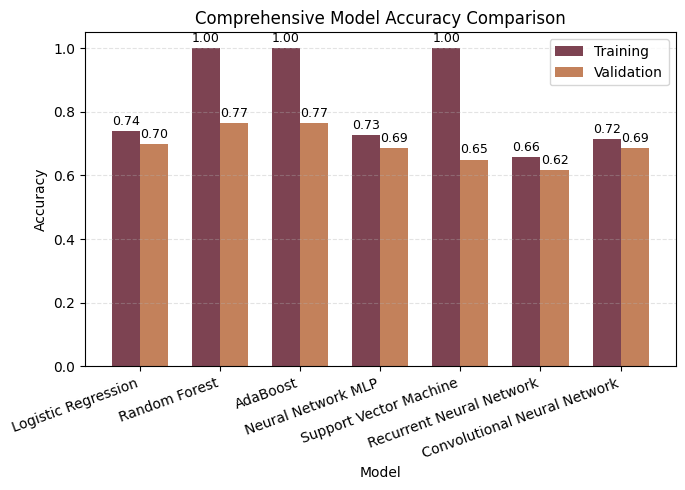

In [ ]:
# Bar chart: training vs validation accuracy for four models (no SVM)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Helper to fetch the first available fitted estimator among several names
def pick(*names):
    g = globals()
    for n in names:
        if n in g and g[n] is not None:
            obj = g[n]
            if hasattr(obj, "predict"):
                return obj
            if hasattr(obj, "best_estimator_") and hasattr(obj.best_estimator_, "predict"):
                return obj.best_estimator_
    raise NameError(f"No valid estimator among: {names}")

# Use ONLY the four requested methods (SVM excluded)
models = {
    "Logistic Regression": pick("log_clf", "grid_search_log"),
    "Random Forest":       pick("best_rf", "rf_clf", "grid_search"),
    "AdaBoost":            pick("best_ada", "ada_clf", "grid_search_ada"),
    "Neural Network MLP":  pick("mlp_clf", "grid_search_mlp"),
    "Support Vector Machine": pick("best_svm", "svm_clf"),
    "Recurrent Neural Network": pick("best_rnn_model", "rnn_model"),
    "Convolutional Neural Network": pick("best_cnn", "cnn_model"),
}

# Compute training and validation accuracy from your existing splits
train_acc = []
val_acc   = []
model_names = list(models.keys())

for name in model_names:
    clf = models[name]
    if name == "Recurrent Neural Network":
        y_pred_train = (clf.predict(X_train_rnn).ravel() >= 0.5).astype(int)
        y_pred_test  = (clf.predict(X_test_rnn).ravel() >= 0.5).astype(int)

    elif name == "Convolutional Neural Network":
        y_pred_train = np.argmax(clf.predict(X_train_cnn), axis=1)
        y_pred_test  = np.argmax(clf.predict(X_test_cnn), axis=1)

    else:
        # Classical ML (LR, RF, AdaBoost, SVM, MLP)
        y_pred_train = clf.predict(X_train)
        y_pred_test  = clf.predict(X_test)

    train_acc.append(accuracy_score(y_train, y_pred_train))
    val_acc.append(accuracy_score(y_test,  y_pred_test))

# Grouped bar plot
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
# Bars for training and validation accuracy
bars1 = ax.bar(x - width/2, train_acc, width, label="Training", color="#7d4352")
bars2 = ax.bar(x + width/2, val_acc,   width, label="Validation", color="#c3815b")

ax.set_title("Comprehensive Model Accuracy Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha="right")
ax.set_ylim(0, max(max(train_acc), max(val_acc)) + 0.05)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend()

# Annotate bar heights
for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.01, f"{h:.2f}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Saving the Trained Models

This cell saves the final trained versions of the Logistic Regression, Random Forest, and AdaBoost models (The best three performing models) so they can be loaded later for testing and prediction.

In [ ]:
# Create folder to store models (if it doesn't exist)
save_path = "/content/drive/MyDrive/Lahjati/Best_models"
os.makedirs(save_path, exist_ok=True)

# 1. Save Logistic Regression model
joblib.dump(log_clf, f"{save_path}/best_logreg.pkl")
print("Saved: best_logreg.pkl")

# 2. Save Random Forest model
joblib.dump(rf_clf, f"{save_path}/best_random_forest.pkl")
print("Saved: best_random_forest.pkl")

# 3. Save AdaBoost model
joblib.dump(ada_clf, f"{save_path}/best_adaboost.pkl")
print("Saved: best_adaboost.pkl")

Saved: best_logreg.pkl
Saved: best_random_forest.pkl
Saved: best_adaboost.pkl
